# T2

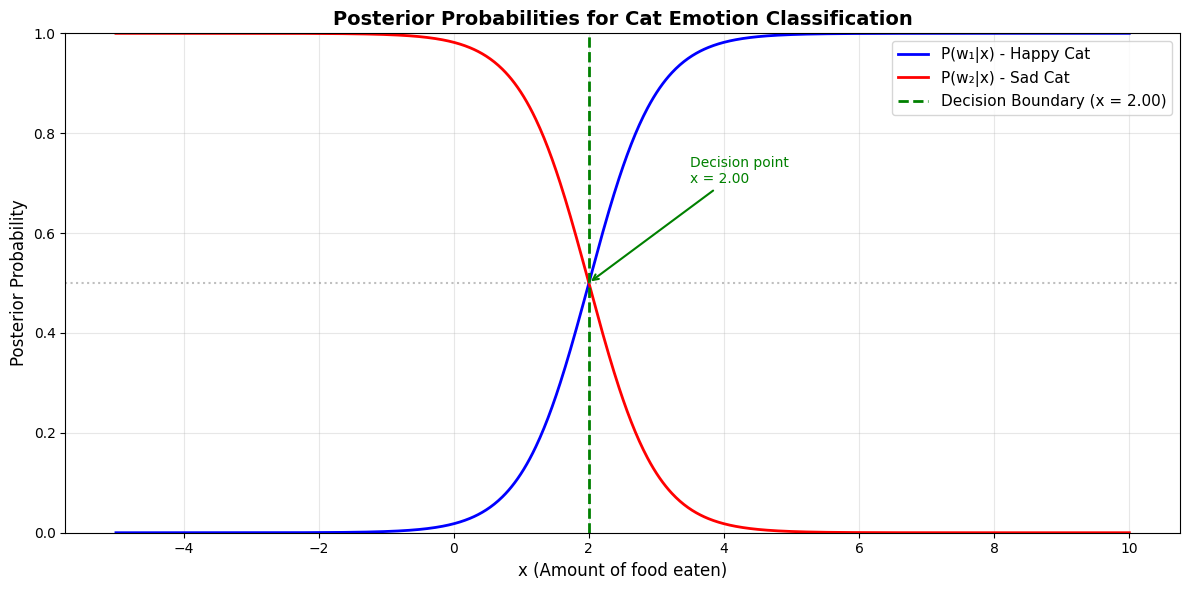

Decision Boundary: x = 1.9970

Decision Rule:
  - If x > 2.00 → Choose w₁ (Happy Cat)
  - If x < 2.00 → Choose w₂ (Sad Cat)


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# กำหนดพารามิเตอร์ของ Gaussian distributions
mu1 = 4      # mean ของ class 1 (happy cat)
mu2 = 0      # mean ของ class 2 (sad cat)
sigma1 = np.sqrt(2)  # std ของ class 1
sigma2 = np.sqrt(2)  # std ของ class 2

# Prior probabilities (เท่ากัน)
P_w1 = 0.5
P_w2 = 0.5

# สร้างช่วงค่า x
x = np.linspace(-5, 10, 1000)

# คำนวณ Likelihood: P(x|w1) และ P(x|w2)
P_x_given_w1 = norm.pdf(x, mu1, sigma1)
P_x_given_w2 = norm.pdf(x, mu2, sigma2)

# คำนวณ Evidence: P(x) = P(x|w1)P(w1) + P(x|w2)P(w2)
P_x = P_x_given_w1 * P_w1 + P_x_given_w2 * P_w2

# คำนวณ Posterior: P(w|x) โดยใช้ Bayes' Theorem
P_w1_given_x = (P_x_given_w1 * P_w1) / P_x
P_w2_given_x = (P_x_given_w2 * P_w2) / P_x

# Plot Posterior Probabilities
plt.figure(figsize=(12, 6))

plt.plot(x, P_w1_given_x, 'b-', linewidth=2, label='P(w₁|x) - Happy Cat')
plt.plot(x, P_w2_given_x, 'r-', linewidth=2, label='P(w₂|x) - Sad Cat')

# หา decision boundary (จุดที่ posterior เท่ากัน)
# หาจุดที่ P(w1|x) = P(w2|x) = 0.5
idx = np.argmin(np.abs(P_w1_given_x - P_w2_given_x))
decision_boundary = x[idx]

# เพิ่มเส้น decision boundary
plt.axvline(x=decision_boundary, color='g', linestyle='--', linewidth=2, 
            label=f'Decision Boundary (x = {decision_boundary:.2f})')
plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)

# ตกแต่งกราฟ
plt.xlabel('x (Amount of food eaten)', fontsize=12)
plt.ylabel('Posterior Probability', fontsize=12)
plt.title('Posterior Probabilities for Cat Emotion Classification', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])

# เพิ่ม annotation
plt.annotate(f'Decision point\nx = {decision_boundary:.2f}', 
             xy=(decision_boundary, 0.5), 
             xytext=(decision_boundary + 1.5, 0.7),
             arrowprops=dict(arrowstyle='->', color='green', lw=1.5),
             fontsize=10, color='green')

plt.tight_layout()
plt.show()

# แสดงค่า decision boundary
print(f"Decision Boundary: x = {decision_boundary:.4f}")
print(f"\nDecision Rule:")
print(f"  - If x > {decision_boundary:.2f} → Choose w₁ (Happy Cat)")
print(f"  - If x < {decision_boundary:.2f} → Choose w₂ (Sad Cat)")

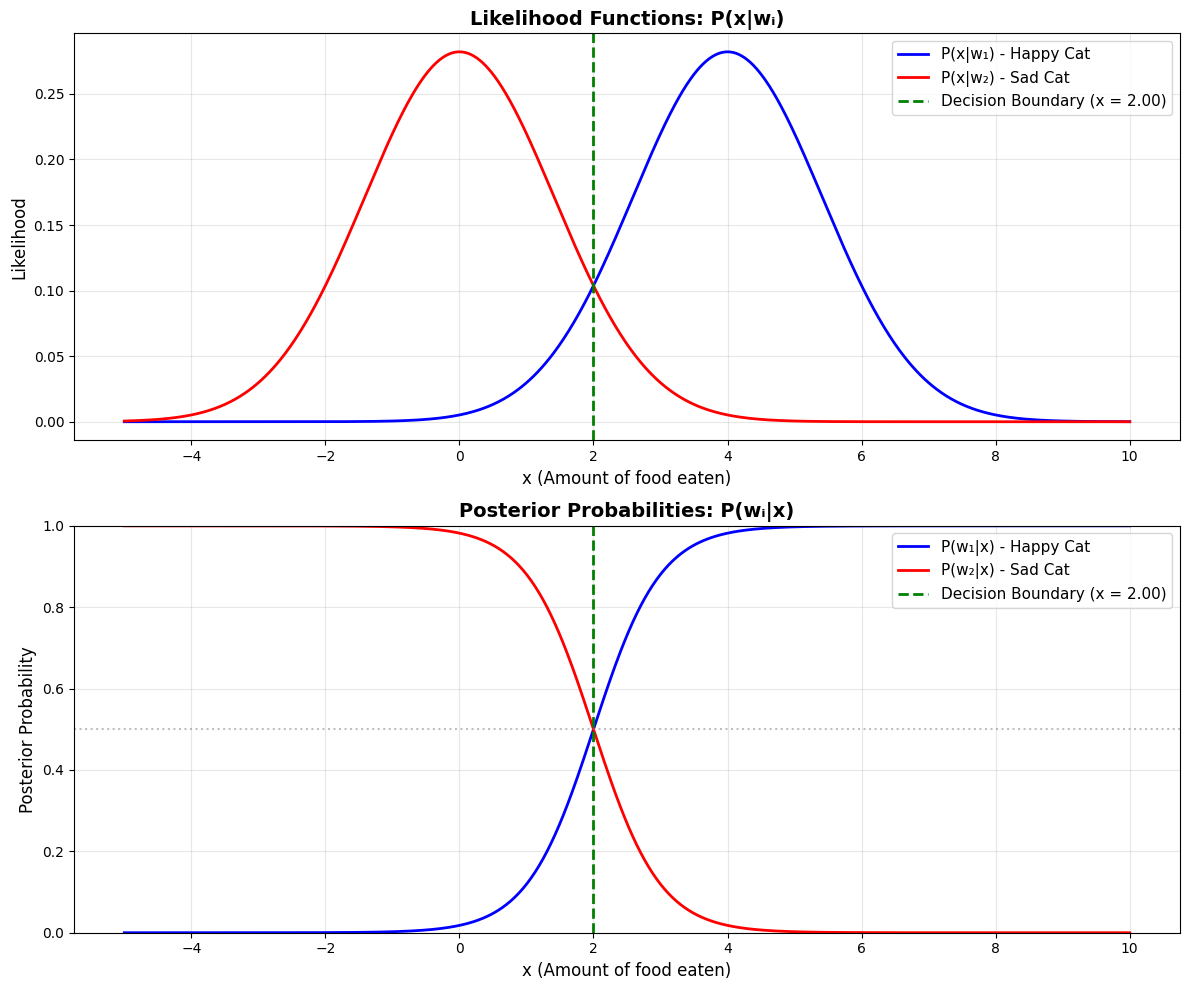

In [2]:
# Plot ทั้ง Likelihood และ Posterior
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Plot 1: Likelihood Functions
ax1.plot(x, P_x_given_w1, 'b-', linewidth=2, label='P(x|w₁) - Happy Cat')
ax1.plot(x, P_x_given_w2, 'r-', linewidth=2, label='P(x|w₂) - Sad Cat')
ax1.axvline(x=decision_boundary, color='g', linestyle='--', linewidth=2, 
            label=f'Decision Boundary (x = {decision_boundary:.2f})')
ax1.set_xlabel('x (Amount of food eaten)', fontsize=12)
ax1.set_ylabel('Likelihood', fontsize=12)
ax1.set_title('Likelihood Functions: P(x|wᵢ)', fontsize=14, fontweight='bold')
ax1.legend(fontsize=11)
ax1.grid(True, alpha=0.3)

# Plot 2: Posterior Probabilities
ax2.plot(x, P_w1_given_x, 'b-', linewidth=2, label='P(w₁|x) - Happy Cat')
ax2.plot(x, P_w2_given_x, 'r-', linewidth=2, label='P(w₂|x) - Sad Cat')
ax2.axvline(x=decision_boundary, color='g', linestyle='--', linewidth=2, 
            label=f'Decision Boundary (x = {decision_boundary:.2f})')
ax2.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)
ax2.set_xlabel('x (Amount of food eaten)', fontsize=12)
ax2.set_ylabel('Posterior Probability', fontsize=12)
ax2.set_title('Posterior Probabilities: P(wᵢ|x)', fontsize=14, fontweight='bold')
ax2.legend(fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.set_ylim([0, 1])

plt.tight_layout()
plt.show()

# OT3

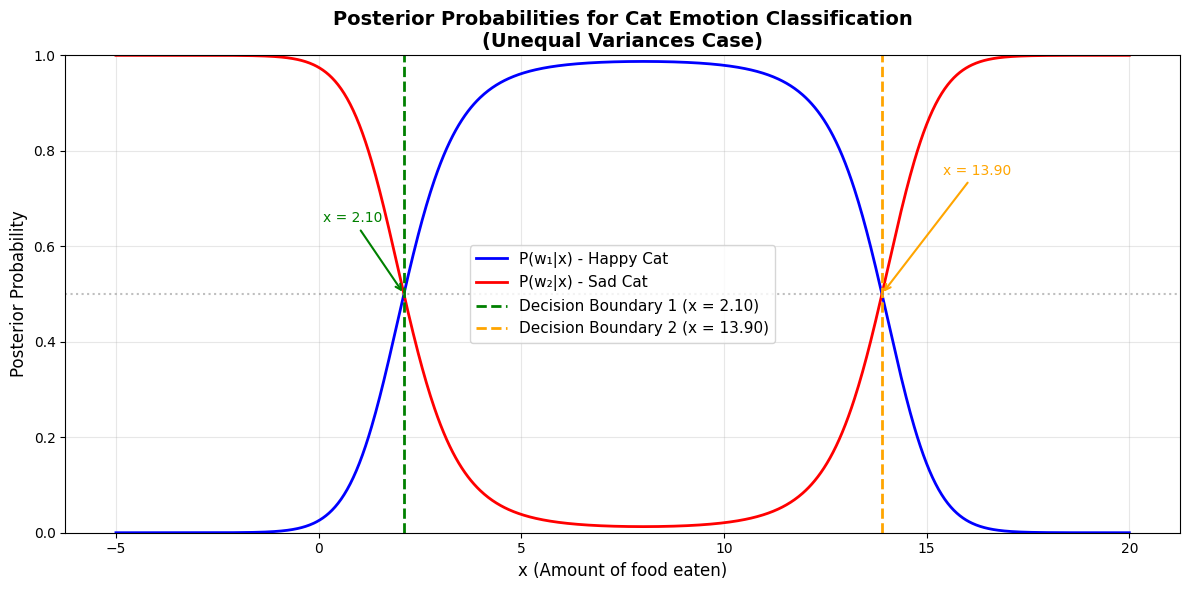

Number of Decision Boundaries: 2
Decision Boundary 1: x = 2.1032
Decision Boundary 2: x = 13.8968

Decision Rule:
  - If 2.10 < x < 13.90 → Choose w₁ (Happy Cat)
  - If x < 2.10 or x > 13.90 → Choose w₂ (Sad Cat)


In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

# กำหนดพารามิเตอร์ของ Gaussian distributions
mu1 = 4      # mean ของ class 1 (happy cat)
mu2 = 0      # mean ของ class 2 (sad cat)
sigma1 = np.sqrt(2)  # std ของ class 1
sigma2 = np.sqrt(4)  # std ของ class 2

# Prior probabilities (เท่ากัน)
P_w1 = 0.5
P_w2 = 0.5

# สร้างช่วงค่า x
x = np.linspace(-5, 20, 1000)

# คำนวณ Likelihood: P(x|w1) และ P(x|w2)
P_x_given_w1 = norm.pdf(x, mu1, sigma1)
P_x_given_w2 = norm.pdf(x, mu2, sigma2)

# คำนวณ Evidence: P(x) = P(x|w1)P(w1) + P(x|w2)P(w2)
P_x = P_x_given_w1 * P_w1 + P_x_given_w2 * P_w2

# คำนวณ Posterior: P(w|x) โดยใช้ Bayes' Theorem
P_w1_given_x = (P_x_given_w1 * P_w1) / P_x
P_w2_given_x = (P_x_given_w2 * P_w2) / P_x

# หา decision boundaries ทั้งหมด (จุดที่ posterior เท่ากัน)
# หาจุดที่ P(w1|x) = P(w2|x) = 0.5
diff = P_w1_given_x - P_w2_given_x
# หาจุดที่เครื่องหมายเปลี่ยน (zero crossings)
sign_changes = np.where(np.diff(np.sign(diff)))[0]

decision_boundaries = []
for idx in sign_changes:
    # ใช้ linear interpolation เพื่อหาค่าที่แม่นยำขึ้น
    x_boundary = x[idx] + (x[idx+1] - x[idx]) * (-diff[idx]) / (diff[idx+1] - diff[idx])
    decision_boundaries.append(x_boundary)

# Plot Posterior Probabilities
plt.figure(figsize=(12, 6))

plt.plot(x, P_w1_given_x, 'b-', linewidth=2, label='P(w₁|x) - Happy Cat')
plt.plot(x, P_w2_given_x, 'r-', linewidth=2, label='P(w₂|x) - Sad Cat')

# เพิ่มเส้น decision boundaries ทั้งหมด
colors = ['green', 'orange']
for i, boundary in enumerate(decision_boundaries):
    plt.axvline(x=boundary, color=colors[i % len(colors)], linestyle='--', 
                linewidth=2, label=f'Decision Boundary {i+1} (x = {boundary:.2f})')

    # เพิ่ม annotation
    plt.annotate(f'x = {boundary:.2f}', 
                 xy=(boundary, 0.5), 
                 xytext=(boundary + (-2 if i == 0 else 1.5), 0.65 + i*0.1),
                 arrowprops=dict(arrowstyle='->', color=colors[i % len(colors)], lw=1.5),
                 fontsize=10, color=colors[i % len(colors)])

plt.axhline(y=0.5, color='gray', linestyle=':', alpha=0.5)

# ตกแต่งกราฟ
plt.xlabel('x (Amount of food eaten)', fontsize=12)
plt.ylabel('Posterior Probability', fontsize=12)
plt.title('Posterior Probabilities for Cat Emotion Classification\n(Unequal Variances Case)', 
          fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.ylim([0, 1])

plt.tight_layout()
plt.show()

# แสดงค่า decision boundaries
print(f"Number of Decision Boundaries: {len(decision_boundaries)}")
for i, boundary in enumerate(decision_boundaries):
    print(f"Decision Boundary {i+1}: x = {boundary:.4f}")

print(f"\nDecision Rule:")
if len(decision_boundaries) == 2:
    print(f"  - If {decision_boundaries[0]:.2f} < x < {decision_boundaries[1]:.2f} → Choose w₁ (Happy Cat)")
    print(f"  - If x < {decision_boundaries[0]:.2f} or x > {decision_boundaries[1]:.2f} → Choose w₂ (Sad Cat)")
else:
    print(f"  - If x > {decision_boundaries[0]:.2f} → Choose w₁ (Happy Cat)")
    print(f"  - If x < {decision_boundaries[0]:.2f} → Choose w₂ (Sad Cat)")

# Employee Attrition Prediction

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv('hr-employee-attrition-with-null.csv')
df.head()

,Unnamed: 0,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,0,41.0,Yes,Travel_Rarely,NaN,NaN,1.0,NaN,Life Sciences,1.0,...,1.0,80.0,0.0,8.0,0.0,NaN,6.0,NaN,0.0,NaN
1,1,NaN,No,NaN,279.0,Research & Development,NaN,NaN,Life Sciences,1.0,...,4.0,NaN,1.0,10.0,NaN,3.0,10.0,NaN,NaN,7.0
2,2,37.0,Yes,NaN,1373.0,NaN,2.0,2.0,NaN,1.0,...,NaN,80.0,0.0,7.0,3.0,NaN,NaN,0.0,NaN,0.0
3,3,NaN,No,Travel_Frequently,1392.0,Research & Development,3.0,4.0,Life Sciences,NaN,...,3.0,NaN,NaN,8.0,3.0,NaN,8.0,NaN,3.0,0.0
4,4,27.0,No,Travel_Rarely,591.0,Research & Development,2.0,1.0,Medical,1.0,...,4.0,80.0,1.0,6.0,NaN,3.0,2.0,2.0,2.0,NaN


In [6]:
df.describe()

,Unnamed: 0,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1176.000000,1176.000000,1176.00000,1176.000000,1176.0,1176.000000,1176.000000,1176.000000,1176.000000,...,1176.000000,1176.0,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000,1176.000000
mean,734.500000,37.134354,798.875850,9.37500,2.920918,1.0,1031.399660,2.733844,65.821429,2.728741,...,2.694728,80.0,0.752551,11.295068,2.787415,2.770408,7.067177,4.290816,2.159014,4.096939
std,424.496761,9.190317,406.957684,8.23049,1.028796,0.0,601.188955,1.092992,20.317323,0.705280,...,1.093660,0.0,0.822550,7.783376,1.290507,0.705004,6.127836,3.630901,3.163524,3.537393
min,0.000000,18.000000,102.000000,1.00000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,367.250000,30.000000,457.750000,2.00000,2.000000,1.0,494.750000,2.000000,48.000000,2.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,734.500000,36.000000,798.500000,7.00000,3.000000,1.0,1027.500000,3.000000,66.000000,3.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,1101.750000,43.000000,1168.250000,15.00000,4.000000,1.0,1562.250000,4.000000,84.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,10.000000,7.000000,2.250000,7.000000
max,1469.000000,60.000000,1499.000000,29.00000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,37.000000,18.000000,15.000000,17.000000


### Feature transformation

In [7]:
df.loc[df["Attrition"] == "no", "Attrition"] = 0.0
df.loc[df["Attrition"] == "yes", "Attrition"] = 1.0
string_categorical_col = ['Department', 'Attrition', 'BusinessTravel', 'EducationField', 'Gender', 'JobRole',
                              'MaritalStatus', 'Over18', 'OverTime']

# ENCODE STRING COLUMNS TO CATEGORICAL COLUMNS
for col in string_categorical_col:
    if col in df.columns:  # ตรวจสอบว่า column มีอยู่จริง
        df[col] = pd.Categorical(df[col]).codes

# HANDLE NULL NUMBERS
# INSERT CODE HERE

df = df.loc[:, ~df.columns.isin(['EmployeeNumber', 'Unnamed: 0', 'EmployeeCount', 'StandardHours', 'Over18'])]

In [8]:
from sklearn.model_selection import train_test_split

In [9]:
df_train, df_test = train_test_split(
    df, 
    test_size=0.1,           # 10% สำหรับ test
    stratify=df['Attrition'], # รักษาสัดส่วนของ Attrition
    random_state=42          # ตั้งค่า seed เพื่อให้ผลลัพธ์ซ้ำได้
)

In [10]:
def display_histogram(df, col_name, cls, n_bin=40):
    """
    แสดง histogram ของ feature ที่ระบุสำหรับ class ที่กำหนด

    Parameters:
    -----------
    df : DataFrame
        ข้อมูลที่ต้องการวิเคราะห์
    col_name : str
        ชื่อ column ที่ต้องการสร้าง histogram
    cls : float or int
        class ที่ต้องการดู (0 = ไม่ลาออก, 1 = ลาออก)
    n_bin : int
        จำนวน bins (default = 40)
    """
    # กรองข้อมูลตาม class ที่ต้องการ
    df_class = df[df['Attrition'] == cls]

    # ลบ NaN values
    col_data = df_class[col_name].dropna()
    # หรือใช้: col_data = df_class[~np.isnan(df_class[col_name])][col_name]

    # สร้าง histogram
    hist, bin_edge = np.histogram(col_data, bins=n_bin)

    # นับจำนวน zero bins
    zero_bins = np.sum(hist == 0)

    # Plot histogram
    plt.figure(figsize=(10, 5))
    plt.fill_between(bin_edge.repeat(2)[1:-1], 
                     hist.repeat(2), 
                     facecolor='steelblue', 
                     alpha=0.7)

    # เพิ่มข้อมูลในกราफ
    class_name = "resign" if cls == 1 else "not resign"
    plt.title(f'Histogram: {col_name} (Class: {class_name})\n'
              f'Bins: {n_bin}, Zero bins: {zero_bins}/{n_bin}', 
              fontsize=12)
    plt.xlabel(col_name, fontsize=10)
    plt.ylabel('Count', fontsize=10)
    plt.grid(alpha=0.3)

    # แสดงสถิติ
    plt.text(0.02, 0.98, 
             f'Mean: {col_data.mean():.2f}\n'
             f'Std: {col_data.std():.2f}\n'
             f'N: {len(col_data)}',
             transform=plt.gca().transAxes,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # พิมพ์ข้อมูลสรุป
    print(f"{col_name} (Class {cls} - {class_name}):")
    print(f"  - Zero bins: {zero_bins}/{n_bin} ({zero_bins/n_bin*100:.1f}%)")
    print(f"  - Data points: {len(col_data)}")
    print(f"  - Range: [{col_data.min():.2f}, {col_data.max():.2f}]")
    print()

    return hist, bin_edge, zero_bins

# T4


Feature: Age


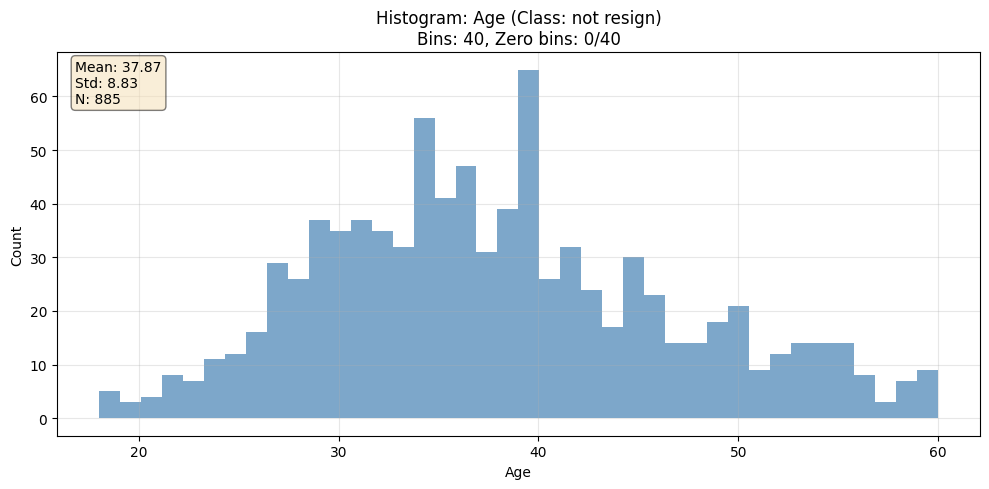

Age (Class 0 - not resign):
  - Zero bins: 0/40 (0.0%)
  - Data points: 885
  - Range: [18.00, 60.00]



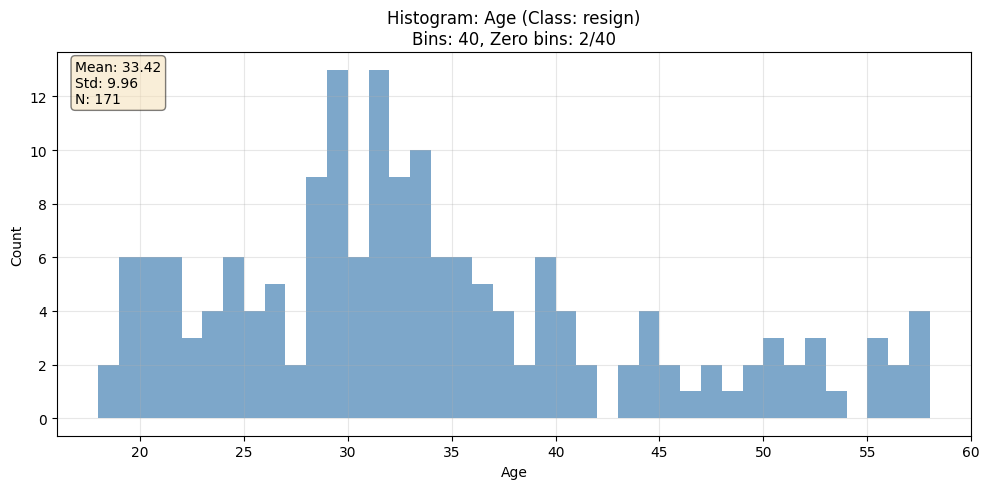

Age (Class 1 - resign):
  - Zero bins: 2/40 (5.0%)
  - Data points: 171
  - Range: [18.00, 58.00]


Feature: MonthlyIncome


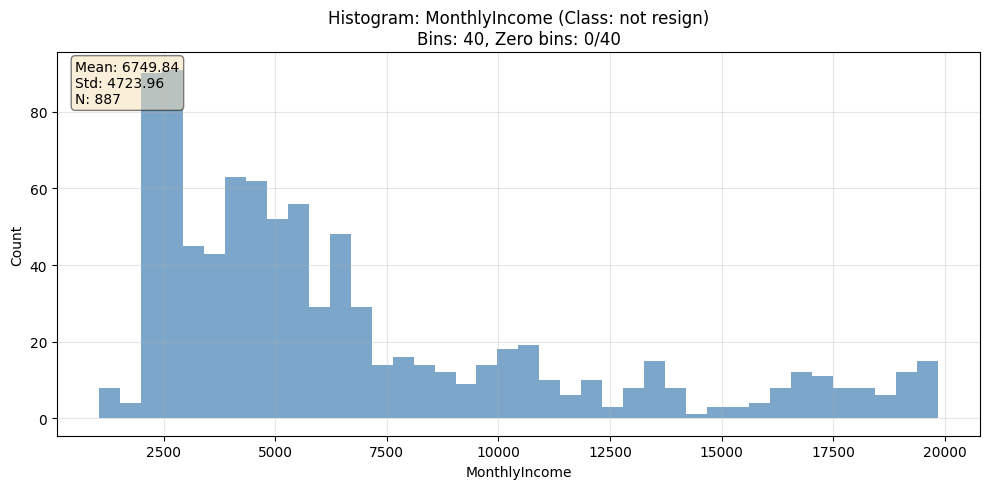

MonthlyIncome (Class 0 - not resign):
  - Zero bins: 0/40 (0.0%)
  - Data points: 887
  - Range: [1051.00, 19847.00]



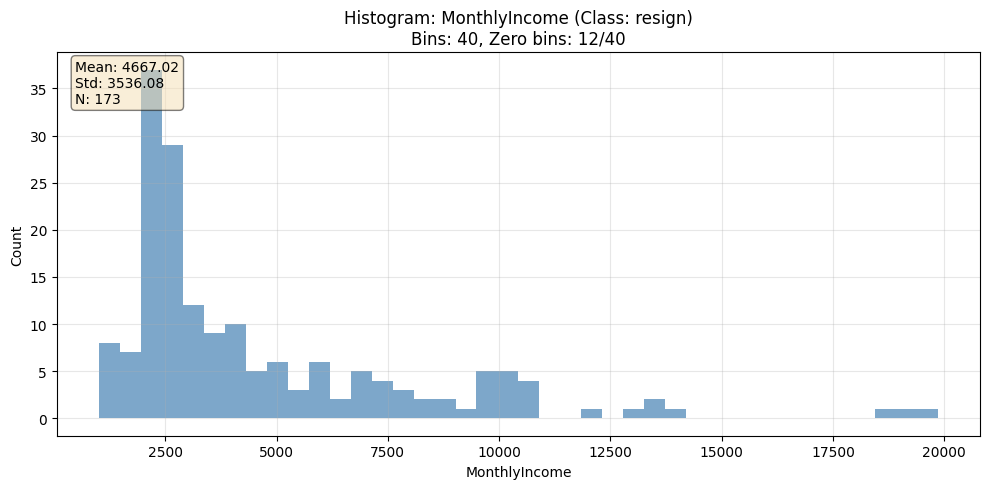

MonthlyIncome (Class 1 - resign):
  - Zero bins: 12/40 (30.0%)
  - Data points: 173
  - Range: [1009.00, 19859.00]


Feature: DistanceFromHome


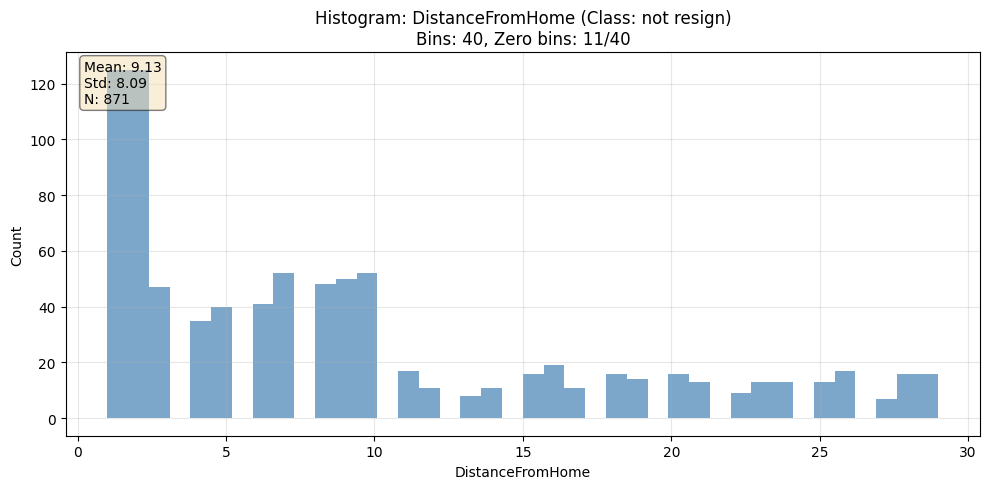

DistanceFromHome (Class 0 - not resign):
  - Zero bins: 11/40 (27.5%)
  - Data points: 871
  - Range: [1.00, 29.00]



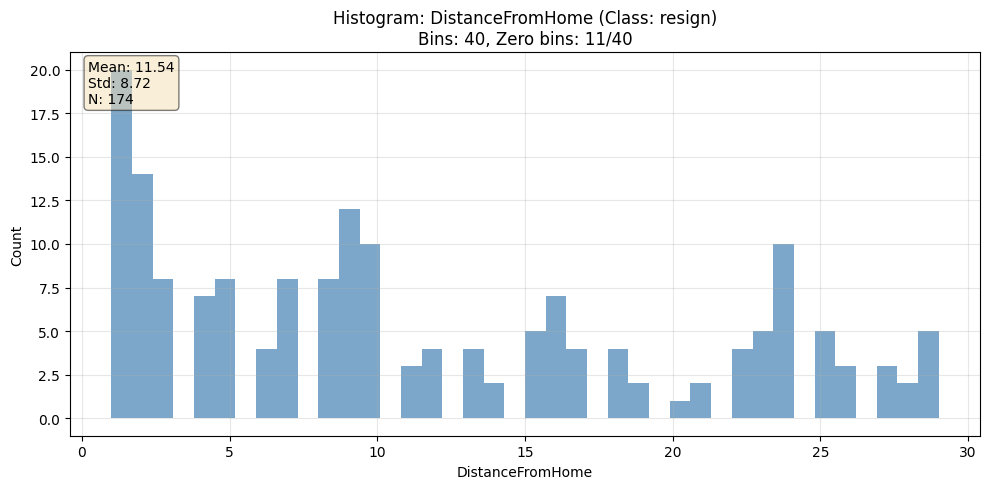

DistanceFromHome (Class 1 - resign):
  - Zero bins: 11/40 (27.5%)
  - Data points: 174
  - Range: [1.00, 29.00]



In [11]:
# วิเคราะห์สำหรับทั้ง 2 classes
features = ['Age', 'MonthlyIncome', 'DistanceFromHome']

for feature in features:
    print(f"\n{'='*60}")
    print(f"Feature: {feature}")
    print('='*60)

    # Class 0 (ไม่ลาออก)
    hist0, bin_edge0, zero0 = display_histogram(df_train, feature, cls=0, n_bin=40)

    # Class 1 (ลาออก)
    hist1, bin_edge1, zero1 = display_histogram(df_train, feature, cls=1, n_bin=40)

## Prepare

In [12]:
def create_bins_and_digitize(df_train, col_name, n_bins=10):
    """
    สร้าง bins และแปลงข้อมูลเป็น discrete values

    Parameters:
    -----------
    df_train : DataFrame
        Training data
    col_name : str
        ชื่อ column ที่ต้องการ discretize
    n_bins : int
        จำนวน bins (default = 10)

    Returns:
    --------
    bin_edges : array
        ขอบเขตของแต่ละ bin (รวม -inf และ inf)
    digitized : array
        ข้อมูลที่ถูกแปลงเป็น bin indices
    """
    # ลบ NaN ออกก่อน
    train_col_no_nan = df_train[col_name].dropna()

    # สร้าง bin edges (ไม่รวม -inf และ inf ก่อน)
    _, bin_edges_temp = np.histogram(train_col_no_nan, bins=n_bins)

    # เพิ่ม -inf และ inf เพื่อครอบคลุมข้อมูลนอกช่วง
    bin_edges = np.concatenate([
        [-np.inf],           # bin แรกเริ่มจาก -inf
        bin_edges_temp[1:-1], # bin ตรงกลาง (ไม่เอาขอบสุด)
        [np.inf]             # bin สุดท้ายถึง inf
    ])

    # Digitize: แปลงข้อมูลเป็น bin indices
    # np.digitize จะ return indices 1, 2, 3, ... (ไม่ใช่ 0-indexed)
    digitized = np.digitize(train_col_no_nan, bin_edges)

    # แปลงเป็น 0-indexed (0, 1, 2, ...)
    digitized = digitized - 1

    return bin_edges, digitized


def count_bins(digitized, n_bins):
    """
    นับจำนวนข้อมูลในแต่ละ bin

    Parameters:
    -----------
    digitized : array
        ข้อมูลที่ถูก digitize แล้ว
    n_bins : int
        จำนวน bins ทั้งหมด

    Returns:
    --------
    counts : array
        จำนวนข้อมูลในแต่ละ bin
    """
    # นับจำนวนในแต่ละ bin
    # minlength เพื่อให้แน่ใจว่ามี bins ครบ (รวม bins ที่เป็น 0)
    counts = np.bincount(digitized, minlength=n_bins)

    return counts

def discretize_feature(df_train, col_name, n_bins=10, verbose=True):
    """
    Discretize feature และแสดงผลลัพธ์

    Parameters:
    -----------
    df_train : DataFrame
        Training data
    col_name : str
        ชื่อ column
    n_bins : int
        จำนวน bins
    verbose : bool
        แสดงผลลัพธ์หรือไม่

    Returns:
    --------
    bin_edges : array
        ขอบเขตของ bins
    digitized : array
        ข้อมูลที่ถูก digitize
    counts : array
        จำนวนในแต่ละ bin
    """
    # สร้าง bins และ digitize
    bin_edges, digitized = create_bins_and_digitize(df_train, col_name, n_bins)

    # นับจำนวนในแต่ละ bin
    counts = count_bins(digitized, n_bins)

    if verbose:
        print(f"\n{'='*60}")
        print(f"Feature: {col_name} | Bins: {n_bins}")
        print('='*60)
        print(f"Bin edges: {bin_edges}")
        print(f"\nBin counts:")
        for i, count in enumerate(counts):
            if i == 0:
                print(f"  Bin {i}: (-inf, {bin_edges[i+1]:.2f}] → {count} samples")
            elif i == len(counts) - 1:
                print(f"  Bin {i}: ({bin_edges[i]:.2f}, inf) → {count} samples")
            else:
                print(f"  Bin {i}: ({bin_edges[i]:.2f}, {bin_edges[i+1]:.2f}] → {count} samples")

        zero_bins = np.sum(counts == 0)
        print(f"\nZero bins: {zero_bins}/{n_bins} ({zero_bins/n_bins*100:.1f}%)")

    return bin_edges, digitized, counts

## T6

In [13]:
def compare_histograms(df_train, col_name, bin_sizes=[10, 40, 100], cls=None):
    """
    เปรียบเทียบ histograms ด้วยจำนวน bins ต่างๆ

    Parameters:
    -----------
    df_train : DataFrame
        Training data
    col_name : str
        ชื่อ column
    bin_sizes : list
        รายการจำนวน bins ที่ต้องการเปรียบเทียบ
    cls : float or None
        class ที่ต้องการดู (None = ทั้งหมด, 0 = ไม่ลาออก, 1 = ลาออก)
    """
    # กรองข้อมูลตาม class (ถ้าระบุ)
    if cls is not None:
        df_filtered = df_train[df_train['Attrition'] == cls]
        title_suffix = f" (Class {int(cls)} - {'Resign' if cls == 1 else 'Not Resign'})"
    else:
        df_filtered = df_train
        title_suffix = " (All Classes)"

    # ลบ NaN
    col_data = df_filtered[col_name].dropna()

    # สร้าง figure ขนาดใหญ่
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    fig.suptitle(f'{col_name}{title_suffix}', fontsize=16, fontweight='bold')

    results = []

    for idx, n_bins in enumerate(bin_sizes):
        ax = axes[idx]

        # สร้าง histogram
        hist, bin_edges = np.histogram(col_data, bins=n_bins)

        # นับ zero bins
        zero_bins = np.sum(hist == 0)
        zero_pct = zero_bins / n_bins * 100

        # Plot
        ax.fill_between(bin_edges.repeat(2)[1:-1], 
                        hist.repeat(2), 
                        facecolor='steelblue', 
                        alpha=0.7,
                        edgecolor='navy',
                        linewidth=0.5)

        # ตกแต่งกราฟ
        ax.set_title(f'{n_bins} Bins\nZero bins: {zero_bins}/{n_bins} ({zero_pct:.1f}%)', 
                    fontsize=12)
        ax.set_xlabel(col_name, fontsize=10)
        ax.set_ylabel('Count', fontsize=10)
        ax.grid(alpha=0.3, linestyle='--')

        # เพิ่มสถิติ
        stats_text = f'Mean: {col_data.mean():.1f}\nStd: {col_data.std():.1f}\nN: {len(col_data)}'
        ax.text(0.98, 0.98, stats_text,
               transform=ax.transAxes,
               verticalalignment='top',
               horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
               fontsize=9)

        # เก็บผลลัพธ์
        results.append({
            'n_bins': n_bins,
            'zero_bins': zero_bins,
            'zero_pct': zero_pct,
            'avg_count': hist.mean(),
            'min_count': hist.min(),
            'max_count': hist.max()
        })

    plt.tight_layout()
    plt.show()

    # แสดงตารางสรุป
    print(f"\n{'='*70}")
    print(f"Summary for {col_name}{title_suffix}")
    print('='*70)
    print(f"{'Bins':<10} {'Zero Bins':<15} {'Zero %':<12} {'Avg Count':<12} {'Min Count':<12}")
    print('-'*70)
    for r in results:
        print(f"{r['n_bins']:<10} {r['zero_bins']:<15} {r['zero_pct']:<12.1f} "
              f"{r['avg_count']:<12.1f} {r['min_count']:<12}")
    print('='*70)

    return results


######################################################################
Analyzing: Age
######################################################################


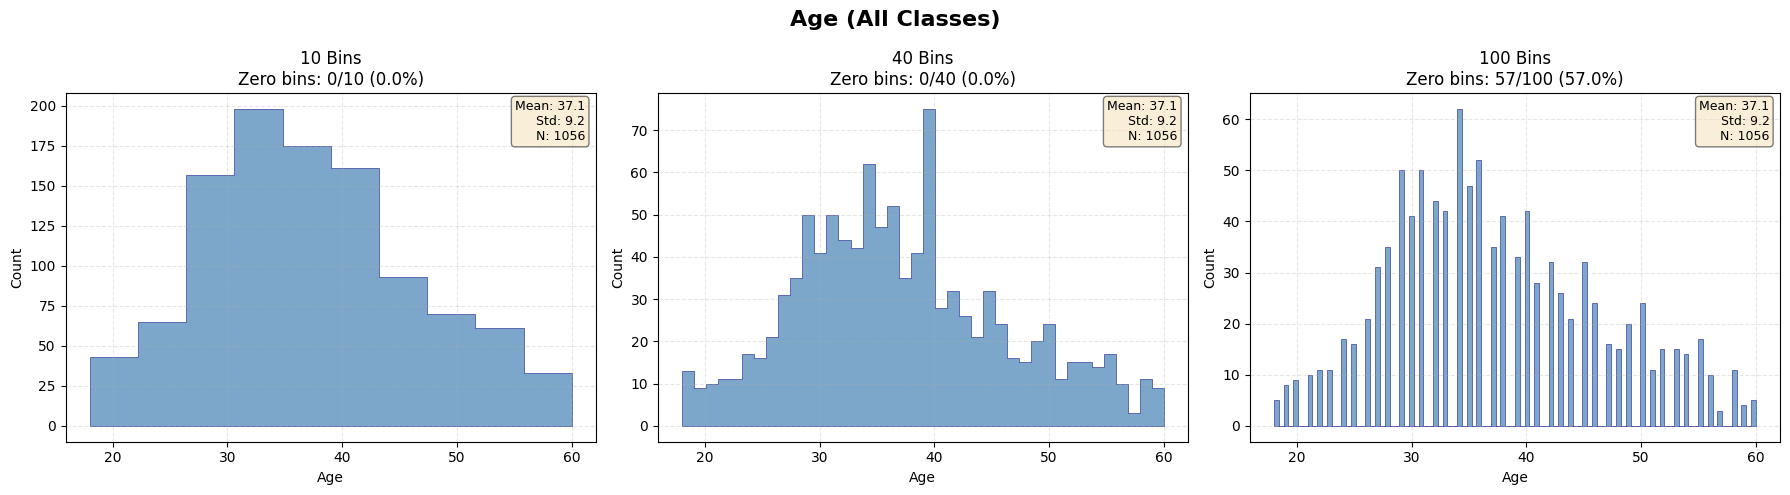


Summary for Age (All Classes)
Bins       Zero Bins       Zero %       Avg Count    Min Count   
----------------------------------------------------------------------
10         0               0.0          105.6        33          
40         0               0.0          26.4         3           
100        57              57.0         10.6         0           

######################################################################
Analyzing: MonthlyIncome
######################################################################


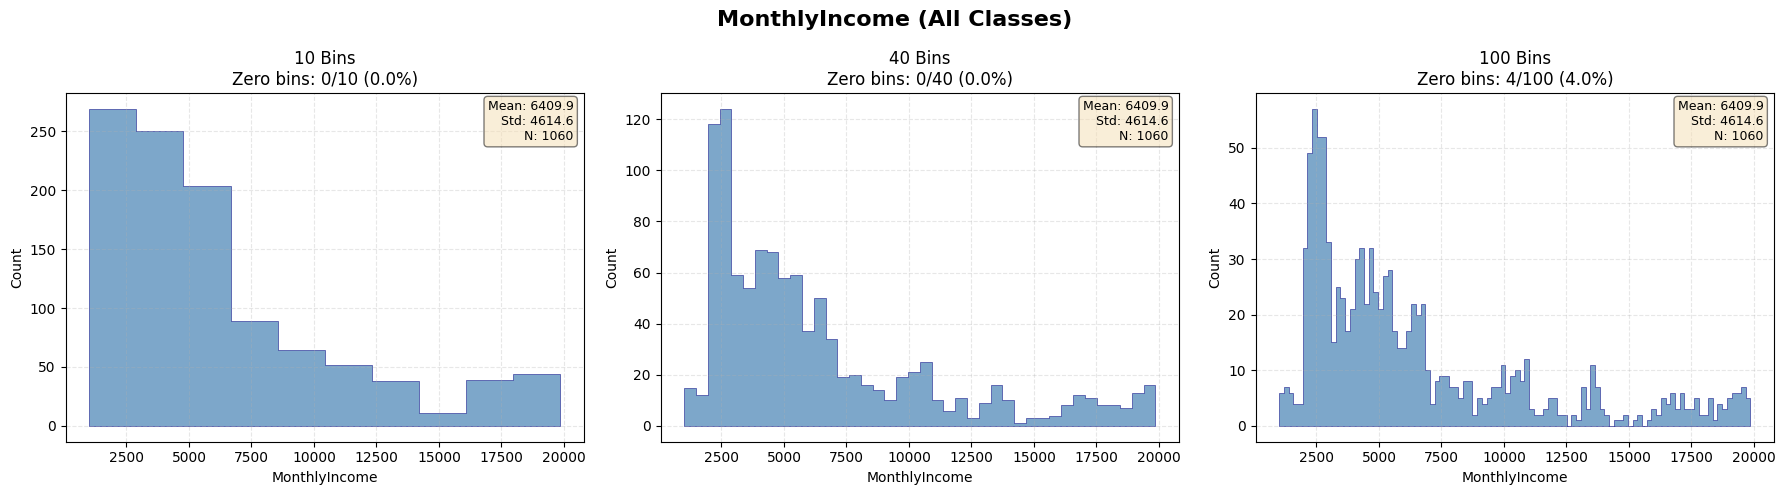


Summary for MonthlyIncome (All Classes)
Bins       Zero Bins       Zero %       Avg Count    Min Count   
----------------------------------------------------------------------
10         0               0.0          106.0        11          
40         0               0.0          26.5         1           
100        4               4.0          10.6         0           

######################################################################
Analyzing: DistanceFromHome
######################################################################


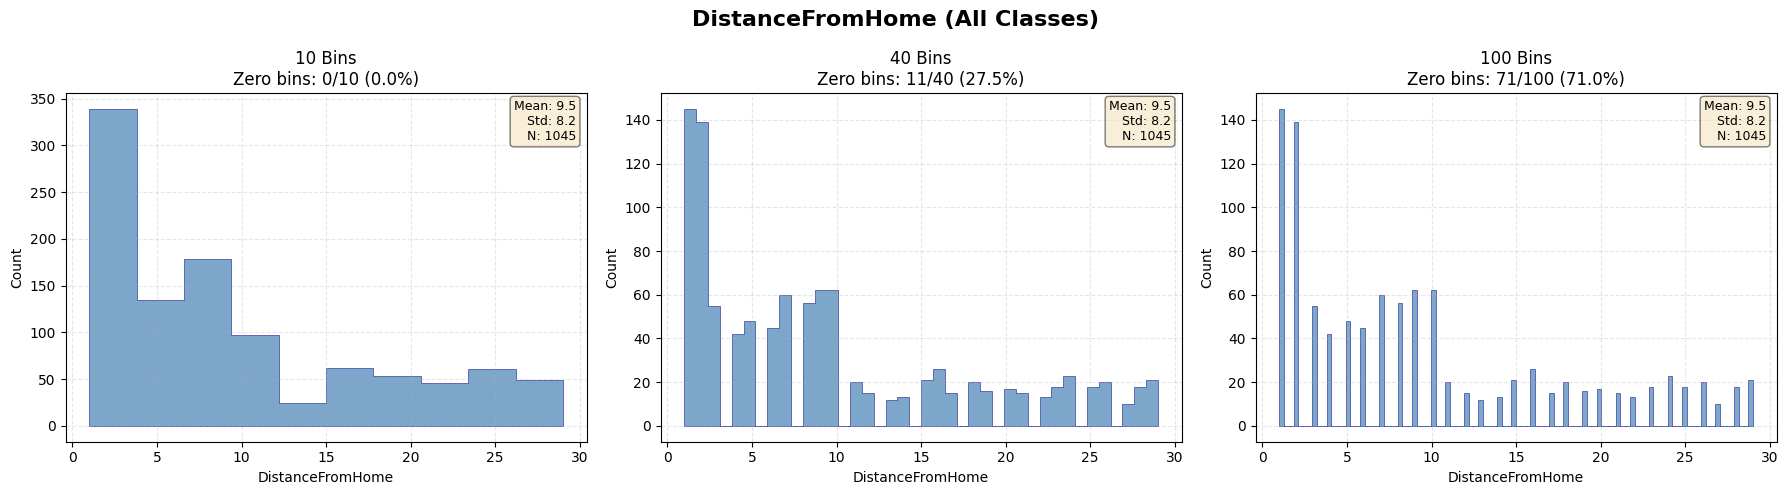


Summary for DistanceFromHome (All Classes)
Bins       Zero Bins       Zero %       Avg Count    Min Count   
----------------------------------------------------------------------
10         0               0.0          104.5        25          
40         11              27.5         26.1         0           
100        71              71.0         10.4         0           


In [14]:
# Features ที่ต้องการวิเคราะห์
features = ['Age', 'MonthlyIncome', 'DistanceFromHome']
bin_sizes = [10, 40, 100]

# เก็บผลลัพธ์ทั้งหมด
all_results = {}

for feature in features:
    print(f"\n{'#'*70}")
    print(f"Analyzing: {feature}")
    print('#'*70)

    # เปรียบเทียบ histograms
    results = compare_histograms(df_train, feature, bin_sizes)
    all_results[feature] = results


######################################################################
Feature: Age
######################################################################

--- Class 0: Not Resign ---


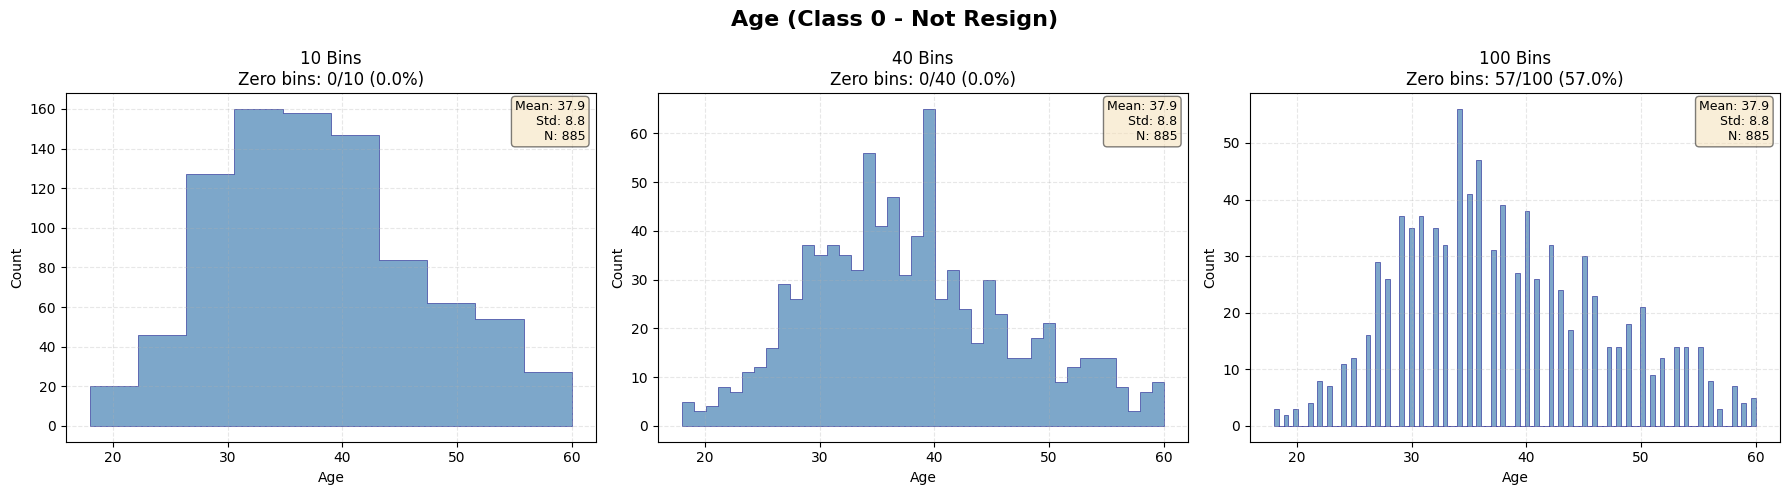


Summary for Age (Class 0 - Not Resign)
Bins       Zero Bins       Zero %       Avg Count    Min Count   
----------------------------------------------------------------------
10         0               0.0          88.5         20          
40         0               0.0          22.1         3           
100        57              57.0         8.8          0           

--- Class 1: Resign ---


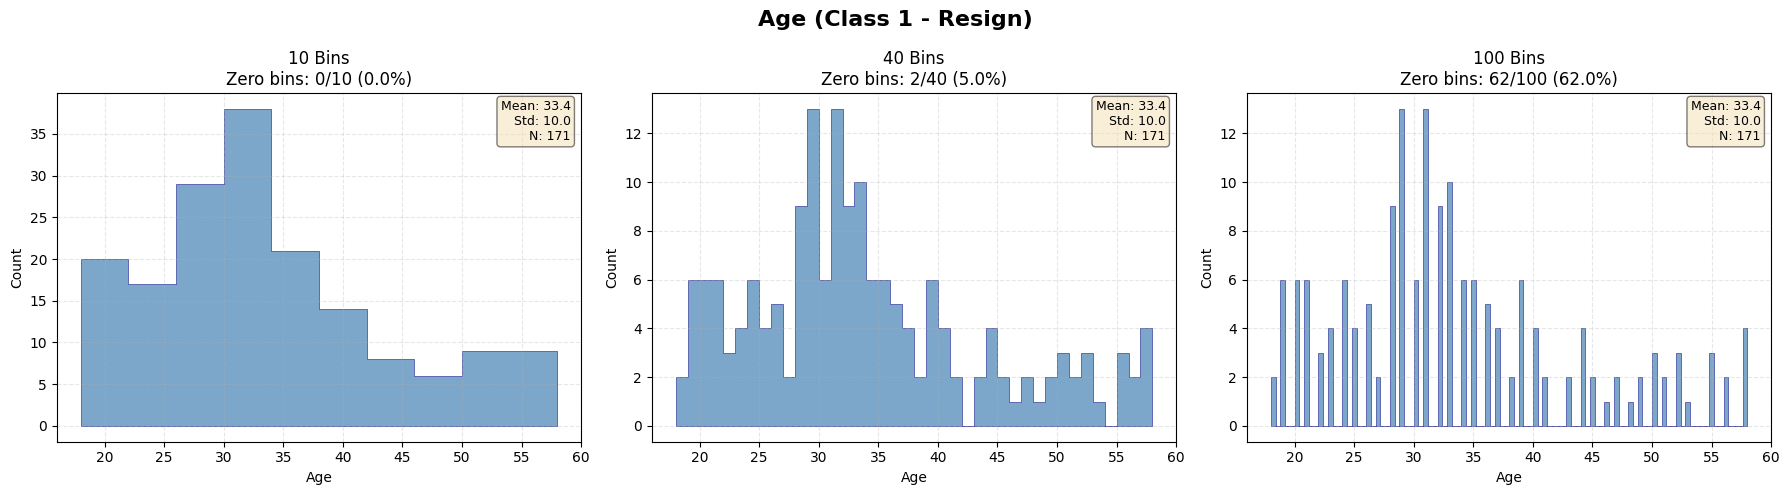


Summary for Age (Class 1 - Resign)
Bins       Zero Bins       Zero %       Avg Count    Min Count   
----------------------------------------------------------------------
10         0               0.0          17.1         6           
40         2               5.0          4.3          0           
100        62              62.0         1.7          0           

######################################################################
Feature: MonthlyIncome
######################################################################

--- Class 0: Not Resign ---


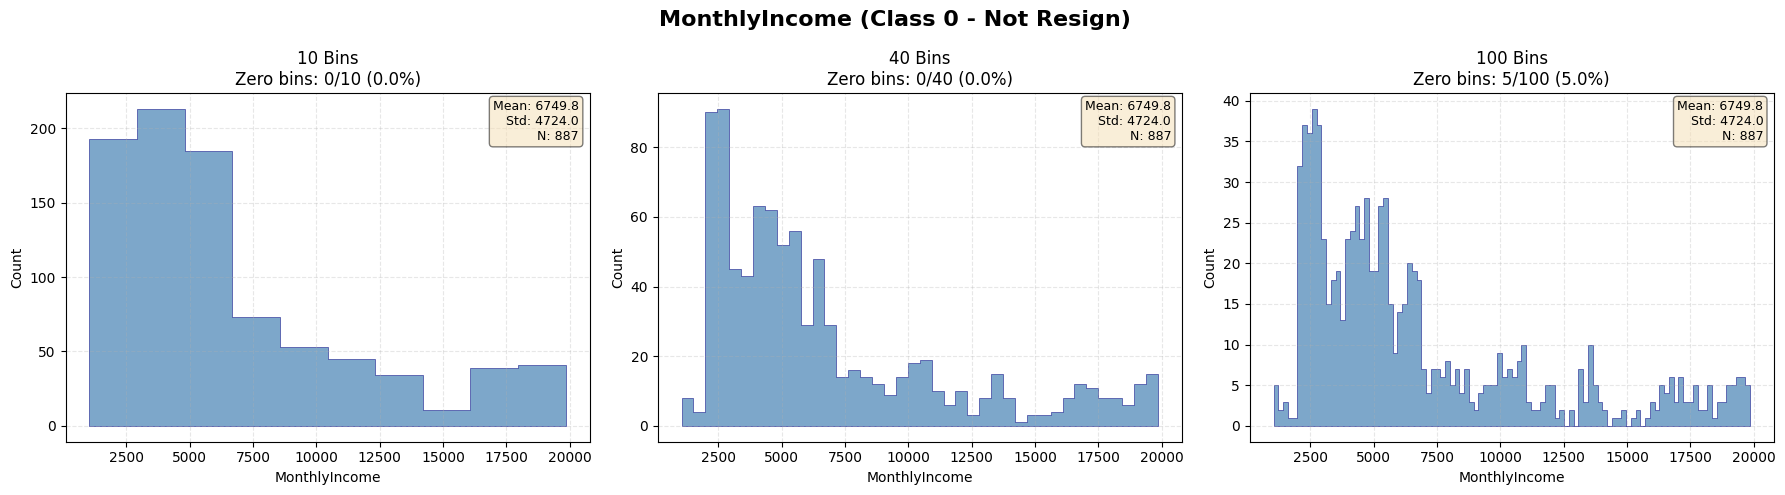


Summary for MonthlyIncome (Class 0 - Not Resign)
Bins       Zero Bins       Zero %       Avg Count    Min Count   
----------------------------------------------------------------------
10         0               0.0          88.7         11          
40         0               0.0          22.2         1           
100        5               5.0          8.9          0           

--- Class 1: Resign ---


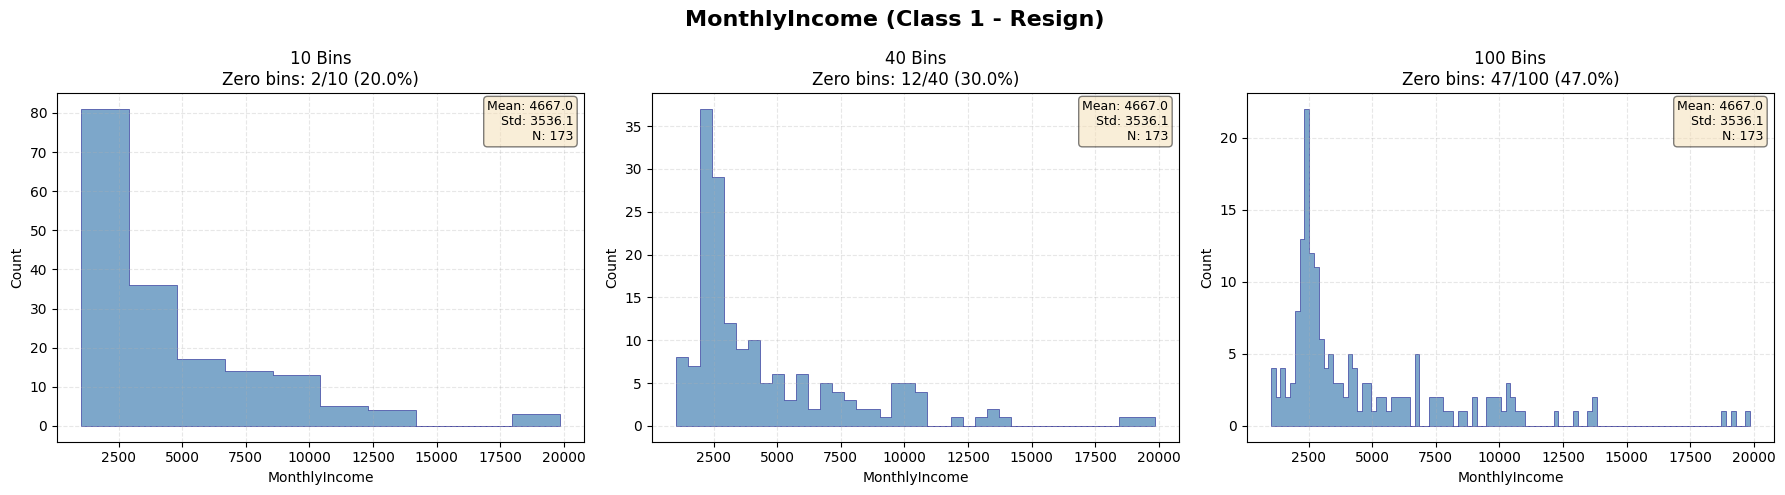


Summary for MonthlyIncome (Class 1 - Resign)
Bins       Zero Bins       Zero %       Avg Count    Min Count   
----------------------------------------------------------------------
10         2               20.0         17.3         0           
40         12              30.0         4.3          0           
100        47              47.0         1.7          0           

######################################################################
Feature: DistanceFromHome
######################################################################

--- Class 0: Not Resign ---


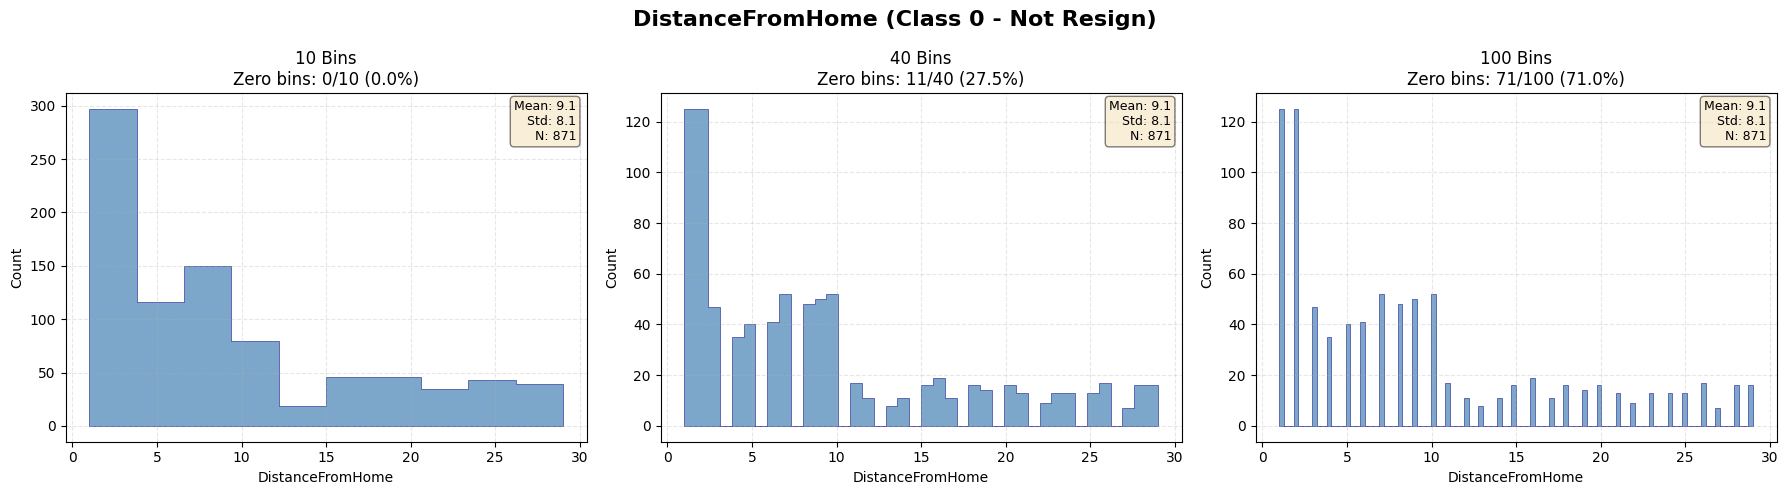


Summary for DistanceFromHome (Class 0 - Not Resign)
Bins       Zero Bins       Zero %       Avg Count    Min Count   
----------------------------------------------------------------------
10         0               0.0          87.1         19          
40         11              27.5         21.8         0           
100        71              71.0         8.7          0           

--- Class 1: Resign ---


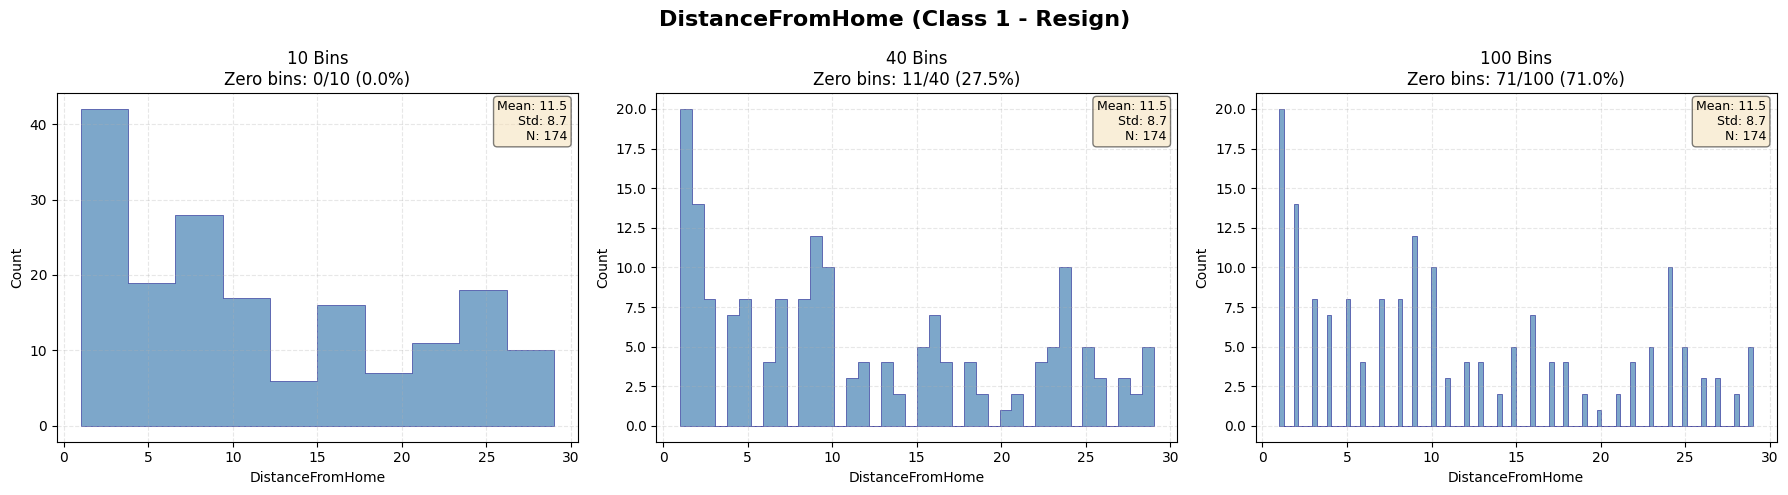


Summary for DistanceFromHome (Class 1 - Resign)
Bins       Zero Bins       Zero %       Avg Count    Min Count   
----------------------------------------------------------------------
10         0               0.0          17.4         6           
40         11              27.5         4.3          0           
100        71              71.0         1.7          0           


In [15]:
# วิเคราะห์แยกตาม Attrition class
for feature in features:
    print(f"\n{'#'*70}")
    print(f"Feature: {feature}")
    print('#'*70)

    # Class 0 (Not Resign)
    print("\n--- Class 0: Not Resign ---")
    compare_histograms(df_train, feature, bin_sizes, cls=0)

    # Class 1 (Resign)
    print("\n--- Class 1: Resign ---")
    compare_histograms(df_train, feature, bin_sizes, cls=1)

## T7

In [16]:
print("All features:")
print(df_train.columns.tolist())
print(f"\nTotal features: {len(df_train.columns)}")

# ดูจำนวนค่าที่ไม่ซ้ำกันของแต่ละ feature
print("\nNumber of unique values per feature:")
for col in df_train.columns:
    n_unique = df_train[col].nunique()
    print(f"{col:<25} {n_unique:>5} unique values")

All features:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

Total features: 31

Number of unique values per feature:
Age                          43 unique values
Attrition                     2 unique values
BusinessTravel                4 unique values
DailyRate                   721 unique values
Department                    4 unique values
DistanceFromHome             29 unique values
Education                     5 unique values
EducationField                7 unique values
Env

In [17]:
features_to_discretize = [
    'DailyRate',
    'HourlyRate',
    'MonthlyRate',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

In [18]:
def discretize_all_continuous_features(df_train, n_bins=10):
    """
    Discretize ทุก continuous features

    Returns:
    --------
    bin_edges_dict : dict
        Dictionary เก็บ bin edges ของแต่ละ feature
    """
    # Features ที่ต้อง discretize
    features_to_discretize = [
        'Age',                      # ทำแล้วใน T6 แต่เก็บไว้ด้วย
        'DailyRate',
        'DistanceFromHome',         # ทำแล้วใน T6
        'HourlyRate',
        'MonthlyIncome',            # ทำแล้วใน T6
        'MonthlyRate',
        'PercentSalaryHike',
        'TotalWorkingYears',
        'YearsAtCompany',
        'YearsInCurrentRole',
        'YearsSinceLastPromotion',
        'YearsWithCurrManager'
    ]

    bin_edges_dict = {}

    print(f"{'='*70}")
    print(f"Discretizing {len(features_to_discretize)} continuous features into {n_bins} bins")
    print(f"{'='*70}\n")

    for feature in features_to_discretize:
        # ตรวจสอบว่า feature มีอยู่ใน dataframe
        if feature not in df_train.columns:
            print(f"⚠️  {feature} not found in dataframe, skipping...")
            continue

        # ลบ NaN
        train_col_no_nan = df_train[feature].dropna()

        if len(train_col_no_nan) == 0:
            print(f"⚠️  {feature} has no valid data, skipping...")
            continue

        # สร้าง bin edges (ไม่รวม -inf และ inf ก่อน)
        _, bin_edges_temp = np.histogram(train_col_no_nan, bins=n_bins)

        # เพิ่ม -inf และ inf
        bin_edges = np.concatenate([
            [-np.inf],
            bin_edges_temp[1:-1],
            [np.inf]
        ])

        # Digitize
        digitized = np.digitize(train_col_no_nan, bin_edges) - 1

        # นับ zero bins
        counts = np.bincount(digitized, minlength=n_bins)
        zero_bins = np.sum(counts == 0)
        zero_pct = zero_bins / n_bins * 100

        # เก็บ bin edges
        bin_edges_dict[feature] = bin_edges

        # แสดงผลลัพธ์
        print(f"✅ {feature:<25} | Range: [{train_col_no_nan.min():.1f}, {train_col_no_nan.max():.1f}] | "
              f"Zero bins: {zero_bins}/{n_bins} ({zero_pct:.1f}%)")

    print(f"\n{'='*70}")
    print(f"Discretization complete! {len(bin_edges_dict)} features processed.")
    print(f"{'='*70}\n")

    return bin_edges_dict


# ใช้งาน
bin_edges_dict = discretize_all_continuous_features(df_train, n_bins=10)

Discretizing 12 continuous features into 10 bins

✅ Age                       | Range: [18.0, 60.0] | Zero bins: 0/10 (0.0%)
✅ DailyRate                 | Range: [102.0, 1499.0] | Zero bins: 0/10 (0.0%)
✅ DistanceFromHome          | Range: [1.0, 29.0] | Zero bins: 0/10 (0.0%)
✅ HourlyRate                | Range: [30.0, 100.0] | Zero bins: 0/10 (0.0%)
✅ MonthlyIncome             | Range: [1009.0, 19859.0] | Zero bins: 0/10 (0.0%)
✅ MonthlyRate               | Range: [2094.0, 26997.0] | Zero bins: 0/10 (0.0%)
✅ PercentSalaryHike         | Range: [11.0, 25.0] | Zero bins: 0/10 (0.0%)
✅ TotalWorkingYears         | Range: [0.0, 40.0] | Zero bins: 0/10 (0.0%)
✅ YearsAtCompany            | Range: [0.0, 37.0] | Zero bins: 0/10 (0.0%)
✅ YearsInCurrentRole        | Range: [0.0, 18.0] | Zero bins: 0/10 (0.0%)
✅ YearsSinceLastPromotion   | Range: [0.0, 15.0] | Zero bins: 0/10 (0.0%)
✅ YearsWithCurrManager      | Range: [0.0, 17.0] | Zero bins: 0/10 (0.0%)

Discretization complete! 12 features proc

In [19]:
def apply_discretization(df, bin_edges_dict, suffix='_binned'):
    """
    Apply discretization ให้กับ dataframe โดยใช้ bin edges ที่กำหนด

    Parameters:
    -----------
    df : DataFrame
        Data ที่ต้องการ discretize
    bin_edges_dict : dict
        Dictionary ของ bin edges
    suffix : str
        Suffix สำหรับ column ใหม่

    Returns:
    --------
    df_binned : DataFrame
        DataFrame ที่มี columns ที่ถูก discretize แล้ว
    """
    df_binned = df.copy()

    for feature, bin_edges in bin_edges_dict.items():
        if feature not in df.columns:
            continue

        # Digitize (จัดการ NaN ด้วย)
        col_data = df[feature].values

        # สร้าง array สำหรับเก็บผลลัพธ์
        digitized = np.full(len(col_data), -1, dtype=int)  # -1 สำหรับ NaN

        # Digitize เฉพาะค่าที่ไม่ใช่ NaN
        valid_mask = ~np.isnan(col_data)
        digitized[valid_mask] = np.digitize(col_data[valid_mask], bin_edges) - 1

        # เก็บใน column ใหม่
        df_binned[feature + suffix] = digitized

        # แปลง -1 กลับเป็น NaN
        df_binned.loc[df_binned[feature + suffix] == -1, feature + suffix] = np.nan

    return df_binned


# Apply ให้กับ training และ test set
df_train_binned = apply_discretization(df_train, bin_edges_dict)
df_test_binned = apply_discretization(df_test, bin_edges_dict)
binned_cols = [col for col in df_train_binned.columns if col.endswith('_binned')]

## T8

In [22]:
def calculate_mle_multinomial(df, feature, bin_edges, cls, n_bins=10):
    """
    คำนวณ MLE สำหรับ Multinomial distribution

    Parameters:
    -----------
    df : DataFrame
        Training data
    feature : str
        ชื่อ feature
    bin_edges : array
        Bin edges สำหรับ discretization
    cls : float
        Class (0 = stay, 1 = leave)
    n_bins : int
        จำนวน bins

    Returns:
    --------
    theta : array
        ความน่าจะเป็นของแต่ละ bin (MLE estimates)
    counts : array
        จำนวนข้อมูลในแต่ละ bin
    """
    # กรองข้อมูลตาม class
    df_class = df[df['Attrition'] == cls]

    # ลบ NaN
    col_data = df_class[feature].dropna()

    # Digitize
    digitized = np.digitize(col_data, bin_edges) - 1

    # นับจำนวนในแต่ละ bin
    counts = np.bincount(digitized, minlength=n_bins)

    # คำนวณ MLE: θ_k = N_k / N
    N = len(col_data)  # จำนวนข้อมูลทั้งหมด
    theta = counts / N  # ความน่าจะเป็นของแต่ละ bin

    return theta, counts


def calculate_mle_categorical(df, feature, cls):
    """
    คำนวณ MLE สำหรับ categorical features (ไม่ต้อง discretize)

    Parameters:
    -----------
    df : DataFrame
        Training data
    feature : str
        ชื่อ feature
    cls : float
        Class (0 = stay, 1 = leave)

    Returns:
    --------
    theta : dict
        ความน่าจะเป็นของแต่ละ category
    counts : dict
        จำนวนข้อมูลในแต่ละ category
    """
    # กรองข้อมูลตาม class
    df_class = df[df['Attrition'] == cls]

    # นับจำนวนในแต่ละ category
    value_counts = df_class[feature].value_counts()

    # คำนวณ MLE
    N = len(df_class[feature].dropna())
    theta = (value_counts / N).to_dict()
    counts = value_counts.to_dict()

    return theta, counts

In [23]:
def plot_likelihood_distribution(df, feature, bin_edges=None, n_bins=10, 
                                 is_categorical=False):
    """
    Plot likelihood distributions สำหรับทั้ง 2 classes

    Parameters:
    -----------
    df : DataFrame
        Training data
    feature : str
        ชื่อ feature
    bin_edges : array or None
        Bin edges (สำหรับ continuous features)
    n_bins : int
        จำนวน bins
    is_categorical : bool
        True ถ้าเป็น categorical feature
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Likelihood Distribution: {feature}', 
                 fontsize=16, fontweight='bold')

    classes = [0, 1]
    class_names = ['Stay (Attrition = 0)', 'Leave (Attrition = 1)']
    colors = ['steelblue', 'coral']

    for idx, (cls, class_name, color) in enumerate(zip(classes, class_names, colors)):
        ax = axes[idx]

        if is_categorical:
            # สำหรับ categorical features
            theta, counts = calculate_mle_categorical(df, feature, cls)

            # เรียงลำดับตาม category
            categories = sorted(theta.keys())
            probs = [theta[cat] for cat in categories]

            # Plot bar chart
            x_pos = np.arange(len(categories))
            ax.bar(x_pos, probs, color=color, alpha=0.7, edgecolor='black')
            ax.set_xticks(x_pos)
            ax.set_xticklabels(categories, rotation=45, ha='right')
            ax.set_xlabel('Category')

        else:
            # สำหรับ continuous features (discretized)
            theta, counts = calculate_mle_multinomial(df, feature, bin_edges, cls, n_bins)

            # Plot histogram-style
            x_pos = np.arange(n_bins)
            ax.bar(x_pos, theta, color=color, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Bin Index')

        ax.set_ylabel('Probability P(x|class)')
        ax.set_title(class_name, fontsize=12)
        ax.grid(alpha=0.3, axis='y')

        # แสดงสถิติ
        total_prob = sum(theta.values()) if is_categorical else theta.sum()
        n_samples = sum(counts.values()) if is_categorical else counts.sum()

        stats_text = f'Total P: {total_prob:.3f}\nN: {n_samples}'
        ax.text(0.98, 0.98, stats_text,
               transform=ax.transAxes,
               verticalalignment='top',
               horizontalalignment='right',
               bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5),
               fontsize=9)

    plt.tight_layout()
    plt.show()

1. MonthlyIncome (Continuous Feature)


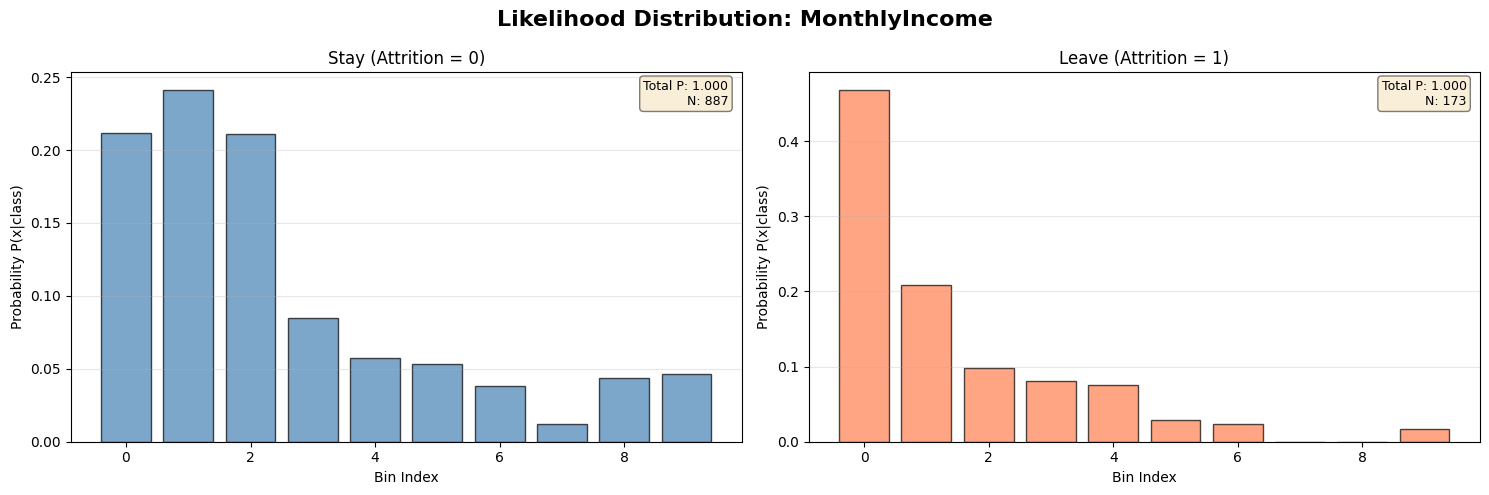


2. JobRole (Categorical Feature)


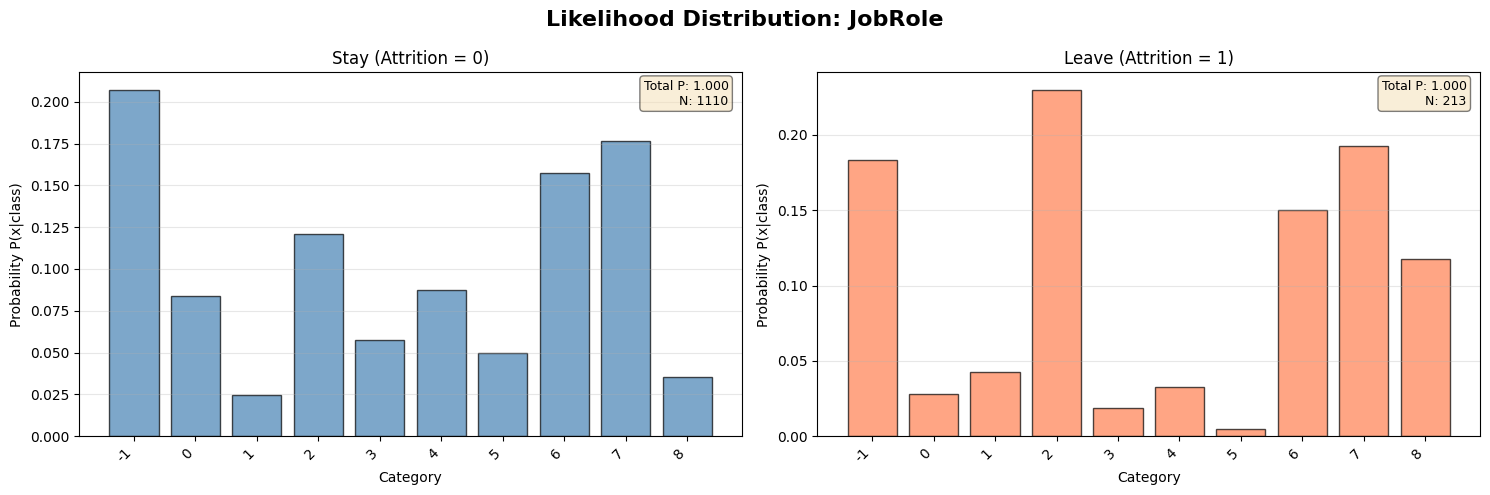


3. HourlyRate (Continuous Feature)


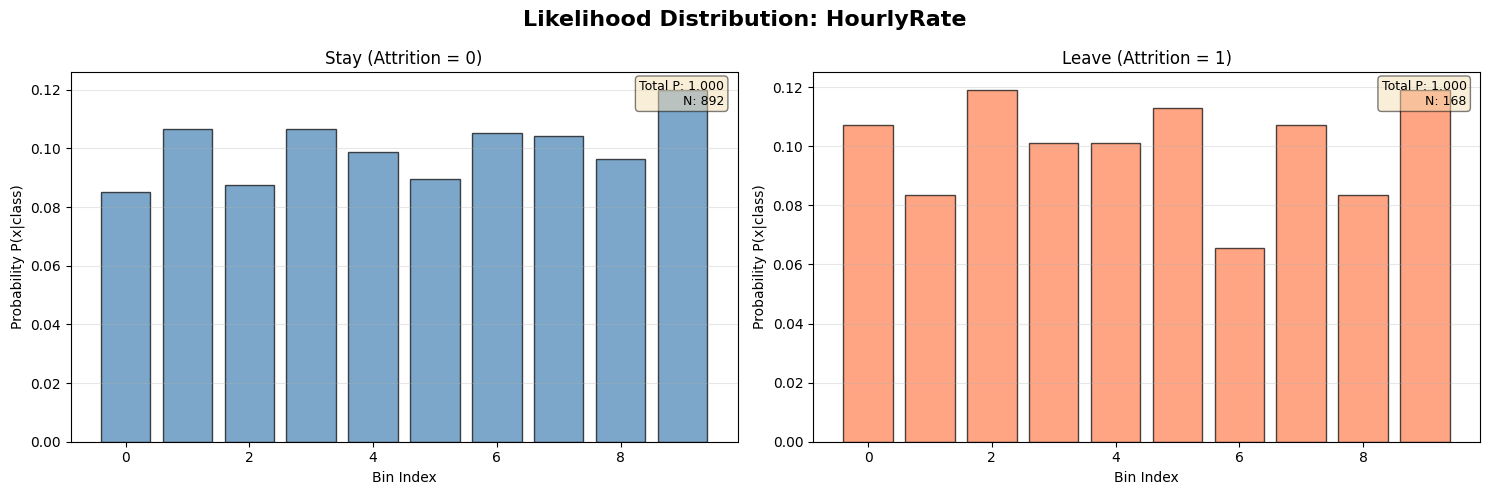


4. MaritalStatus (Categorical Feature)


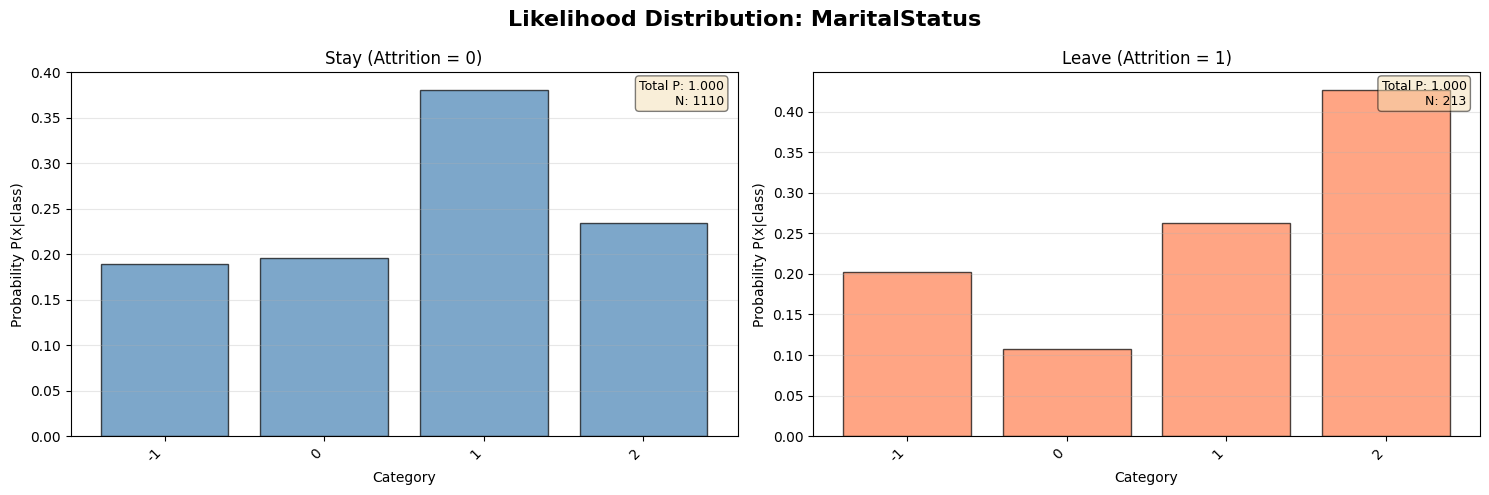

In [24]:
# 1. MonthlyIncome (continuous - ต้อง discretize)
print("=" * 70)
print("1. MonthlyIncome (Continuous Feature)")
print("=" * 70)

# ใช้ bin_edges ที่สร้างไว้แล้ว หรือสร้างใหม่
if 'MonthlyIncome' in bin_edges_dict:
    bin_edges_income = bin_edges_dict['MonthlyIncome']
else:
    _, bin_edges_temp = np.histogram(df_train['MonthlyIncome'].dropna(), bins=10)
    bin_edges_income = np.concatenate([[-np.inf], bin_edges_temp[1:-1], [np.inf]])

plot_likelihood_distribution(df_train, 'MonthlyIncome', 
                            bin_edges=bin_edges_income, 
                            n_bins=10, 
                            is_categorical=False)

# 2. JobRole (categorical - ไม่ต้อง discretize)
print("\n" + "=" * 70)
print("2. JobRole (Categorical Feature)")
print("=" * 70)

plot_likelihood_distribution(df_train, 'JobRole', 
                            is_categorical=True)

# 3. HourlyRate (continuous - ต้อง discretize)
print("\n" + "=" * 70)
print("3. HourlyRate (Continuous Feature)")
print("=" * 70)

if 'HourlyRate' in bin_edges_dict:
    bin_edges_hourly = bin_edges_dict['HourlyRate']
else:
    _, bin_edges_temp = np.histogram(df_train['HourlyRate'].dropna(), bins=10)
    bin_edges_hourly = np.concatenate([[-np.inf], bin_edges_temp[1:-1], [np.inf]])

plot_likelihood_distribution(df_train, 'HourlyRate', 
                            bin_edges=bin_edges_hourly, 
                            n_bins=10, 
                            is_categorical=False)

# 4. MaritalStatus (categorical - ไม่ต้อง discretize)
print("\n" + "=" * 70)
print("4. MaritalStatus (Categorical Feature)")
print("=" * 70)

plot_likelihood_distribution(df_train, 'MaritalStatus', 
                            is_categorical=True)

In [25]:
def print_mle_details(df, feature, bin_edges=None, n_bins=10, is_categorical=False):
    """
    แสดงรายละเอียด MLE สำหรับแต่ละ class
    """
    print(f"\n{'='*70}")
    print(f"MLE Details: {feature}")
    print('='*70)

    for cls in [0, 1]:
        class_name = "Stay" if cls == 0 else "Leave"
        print(f"\n--- Class {int(cls)}: {class_name} ---")

        if is_categorical:
            theta, counts = calculate_mle_categorical(df, feature, cls)
            print(f"\n{'Category':<20} {'Count':<10} {'P(x|class)':<15}")
            print('-'*50)
            for cat in sorted(theta.keys()):
                print(f"{cat:<20} {counts[cat]:<10} {theta[cat]:.6f}")
        else:
            theta, counts = calculate_mle_multinomial(df, feature, bin_edges, cls, n_bins)
            print(f"\n{'Bin':<10} {'Count':<10} {'P(x|class)':<15}")
            print('-'*40)
            for i in range(n_bins):
                print(f"{i:<10} {counts[i]:<10} {theta[i]:.6f}")

        print(f"\nTotal probability: {sum(theta.values()) if is_categorical else theta.sum():.6f}")
        print(f"Total samples: {sum(counts.values()) if is_categorical else counts.sum()}")

# ตัวอย่างการใช้งาน
print_mle_details(df_train, 'MonthlyIncome', bin_edges_income, 10, False)
print_mle_details(df_train, 'JobRole', is_categorical=True)
print_mle_details(df_train, 'HourlyRate', bin_edges_hourly, 10, False)
print_mle_details(df_train, 'MaritalStatus', is_categorical=True)


MLE Details: MonthlyIncome

--- Class 0: Stay ---

Bin        Count      P(x|class)     
----------------------------------------
0          188        0.211950
1          214        0.241263
2          187        0.210823
3          75         0.084555
4          51         0.057497
5          47         0.052988
6          34         0.038331
7          11         0.012401
8          39         0.043968
9          41         0.046223

Total probability: 1.000000
Total samples: 887

--- Class 1: Leave ---

Bin        Count      P(x|class)     
----------------------------------------
0          81         0.468208
1          36         0.208092
2          17         0.098266
3          14         0.080925
4          13         0.075145
5          5          0.028902
6          4          0.023121
7          0          0.000000
8          0          0.000000
9          3          0.017341

Total probability: 1.000000
Total samples: 173

MLE Details: JobRole

--- Class 0: Stay ---

Cat

## T9

In [26]:
def calculate_prior(df_train):
    """
    คำนวณ prior distribution ของทั้ง 2 classes

    Parameters:
    -----------
    df_train : DataFrame
        Training data

    Returns:
    --------
    prior_dict : dict
        Dictionary เก็บ prior probabilities
    """
    # นับจำนวนในแต่ละ class
    class_counts = df_train['Attrition'].value_counts()

    # จำนวนทั้งหมด
    total = len(df_train)

    # คำนวณ prior
    prior_leave = class_counts.get(1.0, 0) / total  # P(leave)
    prior_stay = class_counts.get(0.0, 0) / total   # P(stay)

    # เก็บใน dictionary
    prior_dict = {
        'leave': prior_leave,
        'stay': prior_stay
    }

    # แสดงผลลัพธ์
    print("=" * 60)
    print("Prior Distribution of Classes")
    print("=" * 60)
    print(f"\nP(leave) = P(Attrition = 1) = {prior_leave:.6f}")
    print(f"P(stay)  = P(Attrition = 0) = {prior_stay:.6f}")
    print(f"\nSum of priors: {prior_leave + prior_stay:.6f}")

    print(f"\n--- Class Counts ---")
    print(f"Leave (Attrition = 1): {class_counts.get(1.0, 0)} samples")
    print(f"Stay  (Attrition = 0): {class_counts.get(0.0, 0)} samples")
    print(f"Total: {total} samples")

    print(f"\n--- Ratio ---")
    ratio = prior_stay / prior_leave if prior_leave > 0 else float('inf')
    print(f"Stay:Leave ratio = {ratio:.2f}:1")

    print("=" * 60)

    return prior_dict

# คำนวณ prior
prior_dict = calculate_prior(df_train)

Prior Distribution of Classes

P(leave) = P(Attrition = 1) = 0.160998
P(stay)  = P(Attrition = 0) = 0.839002

Sum of priors: 1.000000

--- Class Counts ---
Leave (Attrition = 1): 213 samples
Stay  (Attrition = 0): 1110 samples
Total: 1323 samples

--- Ratio ---
Stay:Leave ratio = 5.21:1


In [29]:
class NaiveBayesClassifier:
    def __init__(self):
        self.prior = {}
        self.likelihood = {}

    def fit(self, df_train):
        """
        Train Naive Bayes classifier
        """
        # คำนวณ prior
        class_counts = df_train['Attrition'].value_counts()
        total = len(df_train)

        self.prior['leave'] = class_counts.get(1.0, 0) / total
        self.prior['stay'] = class_counts.get(0.0, 0) / total

        print(f"Prior probabilities calculated:")
        print(f"  P(leave) = {self.prior['leave']:.6f}")
        print(f"  P(stay)  = {self.prior['stay']:.6f}")

        # คำนวณ likelihood (จะทำใน T11)
        # ...

    def predict(self, X):
        """
        Predict class for new data
        """
        # ใช้ prior และ likelihood ในการทำนาย
        # ...
        pass

# ตัวอย่างการใช้งาน
nb_classifier = NaiveBayesClassifier()
nb_classifier.fit(df_train)

Prior probabilities calculated:
  P(leave) = 0.160998
  P(stay)  = 0.839002


## T11

In [ ]:
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

class NaiveBayesClassifier:
    def __init__(self, alpha=1.0):
        """
        Naive Bayes Classifier with Laplace Smoothing

        Parameters:
        -----------
        alpha : float
            Smoothing parameter (default = 1.0 for Laplace smoothing)
        """
        self.alpha = alpha
        self.prior = {}
        self.likelihood = {}
        self.bin_edges = {}
        self.continuous_features = []
        self.categorical_features = []

    def fit(self, df_train, continuous_features, categorical_features, 
            bin_edges_dict, n_bins=10):
        """
        Train Naive Bayes classifier

        Parameters:
        -----------
        df_train : DataFrame
            Training data
        continuous_features : list
            List of continuous feature names (discretized)
        categorical_features : list
            List of categorical feature names
        bin_edges_dict : dict
            Dictionary of bin edges for continuous features
        n_bins : int
            Number of bins for discretization
        """
        self.continuous_features = continuous_features
        self.categorical_features = categorical_features
        self.bin_edges = bin_edges_dict
        self.n_bins = n_bins

        # 1. คำนวณ Prior P(class)
        print("=" * 70)
        print("Training Naive Bayes Classifier")
        print("=" * 70)

        class_counts = df_train['Attrition'].value_counts()
        total = len(df_train)

        self.prior['leave'] = class_counts.get(1.0, 0) / total
        self.prior['stay'] = class_counts.get(0.0, 0) / total

        print(f"\n1. Prior Probabilities:")
        print(f"   P(leave) = {self.prior['leave']:.6f}")
        print(f"   P(stay)  = {self.prior['stay']:.6f}")

        # 2. คำนวณ Likelihood P(xi|class) สำหรับแต่ละ feature
        print(f"\n2. Learning Likelihood Distributions...")

        self.likelihood = {
            'leave': {},
            'stay': {}
        }

        # 2.1 Continuous features (discretized)
        for feature in continuous_features:
            if feature not in bin_edges_dict:
                print(f"   ⚠️  {feature} not in bin_edges_dict, skipping...")
                continue

            bin_edges = bin_edges_dict[feature]

            for cls, cls_name in [(1.0, 'leave'), (0.0, 'stay')]:
                theta = self._calculate_likelihood_continuous(
                    df_train, feature, bin_edges, cls, n_bins
                )
                self.likelihood[cls_name][feature] = theta

            print(f"   ✅ {feature} (continuous)")

        # 2.2 Categorical features
        for feature in categorical_features:
            for cls, cls_name in [(1.0, 'leave'), (0.0, 'stay')]:
                theta = self._calculate_likelihood_categorical(
                    df_train, feature, cls
                )
                self.likelihood[cls_name][feature] = theta

            print(f"   ✅ {feature} (categorical)")

        print(f"\n✅ Training complete!")
        print("=" * 70)

    def _calculate_likelihood_continuous(self, df, feature, bin_edges, cls, n_bins):
        """
        คำนวณ likelihood สำหรับ continuous features (with smoothing)
        """
        df_class = df[df['Attrition'] == cls]
        col_data = df_class[feature].dropna()

        # Digitize
        digitized = np.digitize(col_data, bin_edges) - 1

        # Count
        counts = np.bincount(digitized, minlength=n_bins)

        # Apply Laplace smoothing
        N = len(col_data)
        K = n_bins
        theta = (counts + self.alpha) / (N + self.alpha * K)

        return theta

    def _calculate_likelihood_categorical(self, df, feature, cls):
        """
        คำนวณ likelihood สำหรับ categorical features (with smoothing)
        """
        df_class = df[df['Attrition'] == cls]

        # นับจำนวนในแต่ละ category
        value_counts = df_class[feature].value_counts()

        # หา categories ทั้งหมด
        all_categories = df[feature].dropna().unique()
        K = len(all_categories)

        # Apply Laplace smoothing
        N = len(df_class[feature].dropna())
        theta = {}

        for cat in all_categories:
            count = value_counts.get(cat, 0)
            theta[cat] = (count + self.alpha) / (N + self.alpha * K)

        return theta

    def predict(self, df_test):
        """
        Predict class for test data

        Returns:
        --------
        predictions : array
            Predicted classes (0 or 1)
        log_H_values : array
            Log likelihood ratios
        """
        predictions = []
        log_H_values = []

        for idx, row in df_test.iterrows():
            log_H = self._calculate_log_H(row)
            log_H_values.append(log_H)

            # Decision rule
            if log_H > 0:
                predictions.append(1)  # leave
            else:
                predictions.append(0)  # stay

        return np.array(predictions), np.array(log_H_values)

    def _calculate_log_H(self, row):
        """
        คำนวณ log H(x) สำหรับ single sample

        log H(x) = log P(leave) - log P(stay) + Σ[log P(xi|leave) - log P(xi|stay)]
        """
        # Prior term
        log_H = np.log(self.prior['leave']) - np.log(self.prior['stay'])

        # Likelihood terms
        # 1. Continuous features
        for feature in self.continuous_features:
            if feature not in self.bin_edges:
                continue

            # Handle missing values
            if pd.isna(row[feature]):
                continue  # Skip missing features

            # Digitize
            bin_edges = self.bin_edges[feature]
            bin_idx = np.digitize([row[feature]], bin_edges)[0] - 1

            # Clip to valid range
            bin_idx = np.clip(bin_idx, 0, self.n_bins - 1)

            # Get probabilities
            p_leave = self.likelihood['leave'][feature][bin_idx]
            p_stay = self.likelihood['stay'][feature][bin_idx]

            # Add to log H
            log_H += np.log(p_leave) - np.log(p_stay)

        # 2. Categorical features
        for feature in self.categorical_features:
            # Handle missing values
            if pd.isna(row[feature]):
                continue  # Skip missing features

            category = row[feature]

            # Get probabilities (with default for unseen categories)
            p_leave = self.likelihood['leave'][feature].get(category, self.alpha / (1 + self.alpha * len(self.likelihood['leave'][feature])))
            p_stay = self.likelihood['stay'][feature].get(category, self.alpha / (1 + self.alpha * len(self.likelihood['stay'][feature])))

            # Add to log H
            log_H += np.log(p_leave) - np.log(p_stay)

        return log_H

In [33]:
# กำหนด features ที่จะใช้
continuous_features = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

categorical_features = [
    'BusinessTravel',
    'Department',
    'Education',
    'EducationField',
    'EnvironmentSatisfaction',
    'Gender',
    'JobInvolvement',
    'JobLevel',
    'JobRole',
    'JobSatisfaction',
    'MaritalStatus',
    'OverTime',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'WorkLifeBalance'
]

# สร้าง bin edges สำหรับ continuous features (ถ้ายังไม่มี)
if 'bin_edges_dict' not in globals():
    bin_edges_dict = {}
    n_bins = 10

    for feature in continuous_features:
        if feature in df_train.columns:
            col_data = df_train[feature].dropna()
            _, bin_edges_temp = np.histogram(col_data, bins=n_bins)
            bin_edges = np.concatenate([[-np.inf], bin_edges_temp[1:-1], [np.inf]])
            bin_edges_dict[feature] = bin_edges

# สร้างและ train classifier
nb_classifier = NaiveBayesClassifier(alpha=1.0)
nb_classifier.fit(
    df_train, 
    continuous_features, 
    categorical_features, 
    bin_edges_dict, 
    n_bins=10
)

Training Naive Bayes Classifier

1. Prior Probabilities:
   P(leave) = 0.160998
   P(stay)  = 0.839002

2. Learning Likelihood Distributions...
   ✅ Age (continuous)
   ✅ DailyRate (continuous)
   ✅ DistanceFromHome (continuous)
   ✅ HourlyRate (continuous)
   ✅ MonthlyIncome (continuous)
   ✅ MonthlyRate (continuous)
   ✅ PercentSalaryHike (continuous)
   ✅ TotalWorkingYears (continuous)
   ✅ YearsAtCompany (continuous)
   ✅ YearsInCurrentRole (continuous)
   ✅ YearsSinceLastPromotion (continuous)
   ✅ YearsWithCurrManager (continuous)
   ✅ BusinessTravel (categorical)
   ✅ Department (categorical)
   ✅ Education (categorical)
   ✅ EducationField (categorical)
   ✅ EnvironmentSatisfaction (categorical)
   ✅ Gender (categorical)
   ✅ JobInvolvement (categorical)
   ✅ JobLevel (categorical)
   ✅ JobRole (categorical)
   ✅ JobSatisfaction (categorical)
   ✅ MaritalStatus (categorical)
   ✅ OverTime (categorical)
   ✅ PerformanceRating (categorical)
   ✅ RelationshipSatisfaction (categori

In [34]:
# Predict on test set
y_pred, log_H_values = nb_classifier.predict(df_test)
y_true = df_test['Attrition'].values

# คำนวณ metrics
accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, pos_label=1)
recall = recall_score(y_true, y_pred, pos_label=1)
f1 = f1_score(y_true, y_pred, pos_label=1)

# แสดงผลลัพธ์
print("\n" + "=" * 70)
print("T11: Naive Bayes Classification Results")
print("=" * 70)

print(f"\n📊 Overall Performance:")
print(f"   Accuracy  = {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\n🎯 Attrition Detection (Positive Class = Leave):")
print(f"   Precision = {precision:.4f}")
print(f"   Recall    = {recall:.4f}")
print(f"   F-score   = {f1:.4f}")

# Confusion Matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_true, y_pred)
print(f"\n📋 Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Stay  Leave")
print(f"   Actual Stay   {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"   Actual Leave  {cm[1,0]:4d}  {cm[1,1]:4d}")

# คำนวณ metrics เพิ่มเติม
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Detailed Metrics:")
print(f"   True Positives  (TP) = {tp}")
print(f"   False Positives (FP) = {fp}")
print(f"   True Negatives  (TN) = {tn}")
print(f"   False Negatives (FN) = {fn}")

print("=" * 70)



T11: Naive Bayes Classification Results

📊 Overall Performance:
   Accuracy  = 0.7823 (78.23%)

🎯 Attrition Detection (Positive Class = Leave):
   Precision = 0.3462
   Recall    = 0.3750
   F-score   = 0.3600

📋 Confusion Matrix:
                 Predicted
                 Stay  Leave
   Actual Stay    106    17
   Actual Leave    15     9

📈 Detailed Metrics:
   True Positives  (TP) = 9
   False Positives (FP) = 17
   True Negatives  (TN) = 106
   False Negatives (FN) = 15


## T12

In [36]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

class GaussianNaiveBayesClassifier:
    def __init__(self):
        """
        Naive Bayes Classifier using Gaussian PDF for continuous features
        """
        self.prior = {}
        self.gaussian_params = {}  # เก็บ mean และ std
        self.categorical_likelihood = {}  # เก็บ likelihood สำหรับ categorical
        self.continuous_features = []
        self.categorical_features = []

    def fit(self, df_train, continuous_features, categorical_features, alpha=1.0):
        """
        Train Gaussian Naive Bayes classifier

        Parameters:
        -----------
        df_train : DataFrame
            Training data
        continuous_features : list
            List of continuous feature names (จะใช้ Gaussian PDF)
        categorical_features : list
            List of categorical feature names (ยังใช้ multinomial)
        alpha : float
            Smoothing parameter สำหรับ categorical features
        """
        self.continuous_features = continuous_features
        self.categorical_features = categorical_features
        self.alpha = alpha

        # 1. คำนวณ Prior P(class)
        print("=" * 70)
        print("Training Gaussian Naive Bayes Classifier")
        print("=" * 70)

        class_counts = df_train['Attrition'].value_counts()
        total = len(df_train)

        self.prior['leave'] = class_counts.get(1.0, 0) / total
        self.prior['stay'] = class_counts.get(0.0, 0) / total

        print(f"\n1. Prior Probabilities:")
        print(f"   P(leave) = {self.prior['leave']:.6f}")
        print(f"   P(stay)  = {self.prior['stay']:.6f}")

        # 2. คำนวณ Gaussian parameters (μ, σ) สำหรับ continuous features
        print(f"\n2. Learning Gaussian Parameters for Continuous Features...")

        self.gaussian_params = {
            'leave': {},
            'stay': {}
        }

        for feature in continuous_features:
            if feature not in df_train.columns:
                print(f"   ⚠️  {feature} not found, skipping...")
                continue

            for cls, cls_name in [(1.0, 'leave'), (0.0, 'stay')]:
                df_class = df_train[df_train['Attrition'] == cls]
                col_data = df_class[feature].dropna()

                # คำนวณ mean และ std
                mean = col_data.mean()
                std = col_data.std()

                # ป้องกัน std = 0
                if std == 0 or np.isnan(std):
                    std = 1e-6

                self.gaussian_params[cls_name][feature] = {
                    'mean': mean,
                    'std': std
                }

            print(f"   ✅ {feature}: μ_leave={self.gaussian_params['leave'][feature]['mean']:.2f}, "
                  f"σ_leave={self.gaussian_params['leave'][feature]['std']:.2f}")

        # 3. คำนวณ Likelihood สำหรับ categorical features (เหมือน T11)
        print(f"\n3. Learning Likelihood for Categorical Features...")

        self.categorical_likelihood = {
            'leave': {},
            'stay': {}
        }

        for feature in categorical_features:
            if feature not in df_train.columns:
                continue

            for cls, cls_name in [(1.0, 'leave'), (0.0, 'stay')]:
                theta = self._calculate_likelihood_categorical(
                    df_train, feature, cls
                )
                self.categorical_likelihood[cls_name][feature] = theta

            print(f"   ✅ {feature}")

        print(f"\n✅ Training complete!")
        print("=" * 70)

    def _calculate_likelihood_categorical(self, df, feature, cls):
        """
        คำนวณ likelihood สำหรับ categorical features (with Laplace smoothing)
        """
        df_class = df[df['Attrition'] == cls]
        value_counts = df_class[feature].value_counts()

        # หา categories ทั้งหมด
        all_categories = df[feature].dropna().unique()
        K = len(all_categories)

        # Apply Laplace smoothing
        N = len(df_class[feature].dropna())
        theta = {}

        for cat in all_categories:
            count = value_counts.get(cat, 0)
            theta[cat] = (count + self.alpha) / (N + self.alpha * K)

        return theta

    def predict(self, df_test):
        """
        Predict class for test data using Gaussian PDF

        Returns:
        --------
        predictions : array
            Predicted classes (0 or 1)
        log_H_values : array
            Log likelihood ratios
        """
        predictions = []
        log_H_values = []

        for idx, row in df_test.iterrows():
            log_H = self._calculate_log_H(row)
            log_H_values.append(log_H)

            # Decision rule
            if log_H > 0:
                predictions.append(1)  # leave
            else:
                predictions.append(0)  # stay

        return np.array(predictions), np.array(log_H_values)

    def _calculate_log_H(self, row):
        """
        คำนวณ log H(x) โดยใช้ Gaussian PDF สำหรับ continuous features

        log H(x) = log P(leave) - log P(stay) + Σ[log P(xi|leave) - log P(xi|stay)]
        """
        # Prior term
        log_H = np.log(self.prior['leave']) - np.log(self.prior['stay'])

        # 1. Continuous features (ใช้ Gaussian PDF)
        for feature in self.continuous_features:
            if feature not in self.gaussian_params['leave']:
                continue

            # Handle missing values
            if pd.isna(row[feature]):
                continue

            feature_value = row[feature]

            # คำนวณ PDF สำหรับแต่ละ class
            mean_leave = self.gaussian_params['leave'][feature]['mean']
            std_leave = self.gaussian_params['leave'][feature]['std']
            p_leave = norm(mean_leave, std_leave).pdf(feature_value)

            mean_stay = self.gaussian_params['stay'][feature]['mean']
            std_stay = self.gaussian_params['stay'][feature]['std']
            p_stay = norm(mean_stay, std_stay).pdf(feature_value)

            # ป้องกัน log(0)
            if p_leave <= 0:
                p_leave = 1e-10
            if p_stay <= 0:
                p_stay = 1e-10

            # Add to log H
            log_H += np.log(p_leave) - np.log(p_stay)

        # 2. Categorical features (ใช้ multinomial เหมือนเดิม)
        for feature in self.categorical_features:
            if feature not in self.categorical_likelihood['leave']:
                continue

            # Handle missing values
            if pd.isna(row[feature]):
                continue

            category = row[feature]

            # Get probabilities
            p_leave = self.categorical_likelihood['leave'][feature].get(
                category, 
                self.alpha / (1 + self.alpha * len(self.categorical_likelihood['leave'][feature]))
            )
            p_stay = self.categorical_likelihood['stay'][feature].get(
                category,
                self.alpha / (1 + self.alpha * len(self.categorical_likelihood['stay'][feature]))
            )

            # Add to log H
            log_H += np.log(p_leave) - np.log(p_stay)

        return log_H

In [37]:
# กำหนด features
continuous_features = [
    'Age',
    'DailyRate',
    'DistanceFromHome',
    'HourlyRate',
    'MonthlyIncome',
    'MonthlyRate',
    'PercentSalaryHike',
    'TotalWorkingYears',
    'YearsAtCompany',
    'YearsInCurrentRole',
    'YearsSinceLastPromotion',
    'YearsWithCurrManager'
]

categorical_features = [
    'BusinessTravel',
    'Department',
    'Education',
    'EducationField',
    'EnvironmentSatisfaction',
    'Gender',
    'JobInvolvement',
    'JobLevel',
    'JobRole',
    'JobSatisfaction',
    'MaritalStatus',
    'OverTime',
    'PerformanceRating',
    'RelationshipSatisfaction',
    'StockOptionLevel',
    'WorkLifeBalance'
]

# สร้างและ train classifier
gaussian_nb = GaussianNaiveBayesClassifier()
gaussian_nb.fit(df_train, continuous_features, categorical_features, alpha=1.0)

# Predict on test set
y_pred_gaussian, log_H_values_gaussian = gaussian_nb.predict(df_test)
y_true = df_test['Attrition'].values

Training Gaussian Naive Bayes Classifier

1. Prior Probabilities:
   P(leave) = 0.160998
   P(stay)  = 0.839002

2. Learning Gaussian Parameters for Continuous Features...
   ✅ Age: μ_leave=33.42, σ_leave=9.96
   ✅ DailyRate: μ_leave=740.66, σ_leave=410.94
   ✅ DistanceFromHome: μ_leave=11.54, σ_leave=8.72
   ✅ HourlyRate: μ_leave=64.37, σ_leave=20.57
   ✅ MonthlyIncome: μ_leave=4667.02, σ_leave=3536.08
   ✅ MonthlyRate: μ_leave=14334.19, σ_leave=7090.60
   ✅ PercentSalaryHike: μ_leave=15.01, σ_leave=3.78
   ✅ TotalWorkingYears: μ_leave=8.27, σ_leave=7.19
   ✅ YearsAtCompany: μ_leave=4.95, σ_leave=4.96
   ✅ YearsInCurrentRole: μ_leave=3.10, σ_leave=3.29
   ✅ YearsSinceLastPromotion: μ_leave=1.85, σ_leave=3.07
   ✅ YearsWithCurrManager: μ_leave=2.82, σ_leave=3.23

3. Learning Likelihood for Categorical Features...
   ✅ BusinessTravel
   ✅ Department
   ✅ Education
   ✅ EducationField
   ✅ EnvironmentSatisfaction
   ✅ Gender
   ✅ JobInvolvement
   ✅ JobLevel
   ✅ JobRole
   ✅ JobSatisfac

In [38]:
# คำนวณ metrics
accuracy = accuracy_score(y_true, y_pred_gaussian)
precision = precision_score(y_true, y_pred_gaussian, pos_label=1)
recall = recall_score(y_true, y_pred_gaussian, pos_label=1)
f1 = f1_score(y_true, y_pred_gaussian, pos_label=1)

# แสดงผลลัพธ์
print("\n" + "=" * 70)
print("T12: Gaussian Naive Bayes Classification Results")
print("=" * 70)

print(f"\n📊 Overall Performance:")
print(f"   Accuracy  = {accuracy:.4f} ({accuracy*100:.2f}%)")

print(f"\n🎯 Attrition Detection (Positive Class = Leave):")
print(f"   Precision = {precision:.4f}")
print(f"   Recall    = {recall:.4f}")
print(f"   F-score   = {f1:.4f}")

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred_gaussian)
print(f"\n📋 Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Stay  Leave")
print(f"   Actual Stay   {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"   Actual Leave  {cm[1,0]:4d}  {cm[1,1]:4d}")

# Detailed metrics
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Detailed Metrics:")
print(f"   True Positives  (TP) = {tp}")
print(f"   False Positives (FP) = {fp}")
print(f"   True Negatives  (TN) = {tn}")
print(f"   False Negatives (FN) = {fn}")

print("=" * 70)


T12: Gaussian Naive Bayes Classification Results

📊 Overall Performance:
   Accuracy  = 0.7551 (75.51%)

🎯 Attrition Detection (Positive Class = Leave):
   Precision = 0.3235
   Recall    = 0.4583
   F-score   = 0.3793

📋 Confusion Matrix:
                 Predicted
                 Stay  Leave
   Actual Stay    100    23
   Actual Leave    13    11

📈 Detailed Metrics:
   True Positives  (TP) = 11
   False Positives (FP) = 23
   True Negatives  (TN) = 100
   False Negatives (FN) = 13


## T13

In [45]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

def random_choice_baseline(df_test, random_seed=42):
    """
    Random Choice Baseline: ทำนายแบบสุ่ม 50-50

    Parameters:
    -----------
    df_test : DataFrame
        Test data
    random_seed : int
        Random seed for reproducibility

    Returns:
    --------
    y_pred_random : array
        Random predictions
    """
    np.random.seed(random_seed)

    # สุ่มทำนาย: 0 (stay) หรือ 1 (leave) ด้วยความน่าจะเป็น 50-50
    n_samples = len(df_test)
    y_pred_random = np.random.choice([0, 1], size=n_samples, p=[0.5, 0.5])

    return y_pred_random

# ทำนายแบบสุ่ม
y_pred_random = random_choice_baseline(df_test, random_seed=42)
y_true = df_test['Attrition'].values

# คำนวณ metrics
accuracy_random = accuracy_score(y_true, y_pred_random)
precision_random = precision_score(y_true, y_pred_random, pos_label=1, zero_division=0)
recall_random = recall_score(y_true, y_pred_random, pos_label=1, zero_division=0)
f1_random = f1_score(y_true, y_pred_random, pos_label=1, zero_division=0)

# แสดงผลลัพธ์
print("=" * 70)
print("T13: Random Choice Baseline Results")
print("=" * 70)

print(f"\n📊 Overall Performance:")
print(f"   Accuracy  = {accuracy_random:.4f} ({accuracy_random*100:.2f}%)")

print(f"\n🎯 Attrition Detection (Positive Class = Leave):")
print(f"   Precision = {precision_random:.4f}")
print(f"   Recall    = {recall_random:.4f}")
print(f"   F-score   = {f1_random:.4f}")

# Confusion Matrix
cm_random = confusion_matrix(y_true, y_pred_random)
print(f"\n📋 Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Stay  Leave")
print(f"   Actual Stay   {cm_random[0,0]:4d}  {cm_random[0,1]:4d}")
print(f"   Actual Leave  {cm_random[1,0]:4d}  {cm_random[1,1]:4d}")

# Detailed metrics
tn, fp, fn, tp = cm_random.ravel()
print(f"\n📈 Detailed Metrics:")
print(f"   True Positives  (TP) = {tp}")
print(f"   False Positives (FP) = {fp}")
print(f"   True Negatives  (TN) = {tn}")
print(f"   False Negatives (FN) = {fn}")

print("=" * 70)

T13: Random Choice Baseline Results

📊 Overall Performance:
   Accuracy  = 0.4898 (48.98%)

🎯 Attrition Detection (Positive Class = Leave):
   Precision = 0.1304
   Recall    = 0.3750
   F-score   = 0.1935

📋 Confusion Matrix:
                 Predicted
                 Stay  Leave
   Actual Stay     63    60
   Actual Leave    15     9

📈 Detailed Metrics:
   True Positives  (TP) = 9
   False Positives (FP) = 60
   True Negatives  (TN) = 63
   False Negatives (FN) = 15


## T14

In [46]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# ===== T14: Majority Rule Baseline =====

# 1. หา majority class จาก training set
class_counts = df_train['Attrition'].value_counts()
majority_class = class_counts.idxmax()  # class ที่มีมากที่สุด

print("=" * 70)
print("T14: Majority Rule Baseline")
print("=" * 70)

print(f"\n📊 Training Set Class Distribution:")
print(f"   Stay  (0): {class_counts.get(0.0, 0)} samples ({class_counts.get(0.0, 0)/len(df_train)*100:.2f}%)")
print(f"   Leave (1): {class_counts.get(1.0, 0)} samples ({class_counts.get(1.0, 0)/len(df_train)*100:.2f}%)")
print(f"\n   → Majority Class: {int(majority_class)} ({'Stay' if majority_class == 0 else 'Leave'})")

# 2. ทำนายทุกตัวอย่างเป็น majority class
y_pred_majority = np.full(len(df_test), majority_class)
y_true = df_test['Attrition'].values

# 3. คำนวณ metrics
accuracy_majority = accuracy_score(y_true, y_pred_majority)
precision_majority = precision_score(y_true, y_pred_majority, pos_label=1, zero_division=0)
recall_majority = recall_score(y_true, y_pred_majority, pos_label=1, zero_division=0)
f1_majority = f1_score(y_true, y_pred_majority, pos_label=1, zero_division=0)

# 4. แสดงผลลัพธ์
print(f"\n📊 Overall Performance:")
print(f"   Accuracy  = {accuracy_majority:.4f} ({accuracy_majority*100:.2f}%)")

print(f"\n🎯 Attrition Detection (Positive Class = Leave):")
print(f"   Precision = {precision_majority:.4f}")
print(f"   Recall    = {recall_majority:.4f}")
print(f"   F-score   = {f1_majority:.4f}")

# 5. Confusion Matrix
cm = confusion_matrix(y_true, y_pred_majority)
print(f"\n📋 Confusion Matrix:")
print(f"                 Predicted")
print(f"                 Stay  Leave")
print(f"   Actual Stay   {cm[0,0]:4d}  {cm[0,1]:4d}")
print(f"   Actual Leave  {cm[1,0]:4d}  {cm[1,1]:4d}")

# 6. Detailed metrics
tn, fp, fn, tp = cm.ravel()
print(f"\n📈 Detailed Metrics:")
print(f"   True Positives  (TP) = {tp}")
print(f"   False Positives (FP) = {fp}")
print(f"   True Negatives  (TN) = {tn}")
print(f"   False Negatives (FN) = {fn}")

print("=" * 70)

T14: Majority Rule Baseline

📊 Training Set Class Distribution:
   Stay  (0): 1110 samples (83.90%)
   Leave (1): 213 samples (16.10%)

   → Majority Class: 0 (Stay)

📊 Overall Performance:
   Accuracy  = 0.8367 (83.67%)

🎯 Attrition Detection (Positive Class = Leave):
   Precision = 0.0000
   Recall    = 0.0000
   F-score   = 0.0000

📋 Confusion Matrix:
                 Predicted
                 Stay  Leave
   Actual Stay    123     0
   Actual Leave    24     0

📈 Detailed Metrics:
   True Positives  (TP) = 0
   False Positives (FP) = 0
   True Negatives  (TN) = 123
   False Negatives (FN) = 24


## T16

In [52]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

# ===== T16: Threshold Finding =====

def find_best_thresholds(y_true, log_H_values, thresholds=None):
    """
    หา threshold ที่ดีที่สุดสำหรับ Accuracy และ F-score

    Parameters:
    -----------
    y_true : array
        Ground truth labels
    log_H_values : array
        Log likelihood ratios from Naive Bayes
    thresholds : array
        Array of threshold values to try (default: np.arange(-5, 5, 0.05))

    Returns:
    --------
    results : dict
        Dictionary containing best thresholds and corresponding metrics
    """

    if thresholds is None:
        thresholds = np.arange(-5, 5, 0.05)

    print("=" * 70)
    print("T16: Threshold Finding")
    print("=" * 70)

    # เก็บผลลัพธ์
    accuracies = []
    precisions = []
    recalls = []
    f1_scores = []

    # ลองทุก threshold
    for t in thresholds:
        # ทำนายโดยใช้ threshold t
        y_pred = (log_H_values > t).astype(int)

        # คำนวณ metrics
        acc = accuracy_score(y_true, y_pred)
        prec = precision_score(y_true, y_pred, pos_label=1, zero_division=0)
        rec = recall_score(y_true, y_pred, pos_label=1, zero_division=0)
        f1 = f1_score(y_true, y_pred, pos_label=1, zero_division=0)

        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)

    # แปลงเป็น numpy arrays
    accuracies = np.array(accuracies)
    precisions = np.array(precisions)
    recalls = np.array(recalls)
    f1_scores = np.array(f1_scores)

    # หา best thresholds
    best_acc_idx = np.argmax(accuracies)
    best_f1_idx = np.argmax(f1_scores)

    best_acc_threshold = thresholds[best_acc_idx]
    best_acc = accuracies[best_acc_idx]

    best_f1_threshold = thresholds[best_f1_idx]
    best_f1 = f1_scores[best_f1_idx]

    # แสดงผลลัพธ์
    print(f"\n🎯 Best Accuracy:")
    print(f"   Threshold = {best_acc_threshold:.2f}")
    print(f"   Accuracy  = {best_acc:.4f} ({best_acc*100:.2f}%)")

    # แสดง metrics อื่นๆ ที่ threshold นี้
    print(f"   Precision = {precisions[best_acc_idx]:.4f}")
    print(f"   Recall    = {recalls[best_acc_idx]:.4f}")
    print(f"   F-score   = {f1_scores[best_acc_idx]:.4f}")

    print(f"\n🎯 Best F-score:")
    print(f"   Threshold = {best_f1_threshold:.2f}")
    print(f"   F-score   = {best_f1:.4f}")

    # แสดง metrics อื่นๆ ที่ threshold นี้
    print(f"   Accuracy  = {accuracies[best_f1_idx]:.4f} ({accuracies[best_f1_idx]*100:.2f}%)")
    print(f"   Precision = {precisions[best_f1_idx]:.4f}")
    print(f"   Recall    = {recalls[best_f1_idx]:.4f}")

    # เปรียบเทียบกับ default threshold (t=0)
    default_idx = np.argmin(np.abs(thresholds - 0))
    print(f"\n📊 Comparison with Default Threshold (t=0):")
    print(f"   Default Accuracy  = {accuracies[default_idx]:.4f}")
    print(f"   Default F-score   = {f1_scores[default_idx]:.4f}")
    print(f"\n   Improvement:")
    print(f"   Accuracy: {best_acc - accuracies[default_idx]:+.4f}")
    print(f"   F-score:  {best_f1 - f1_scores[default_idx]:+.4f}")

    print("=" * 70)

    # เก็บผลลัพธ์
    results = {
        'thresholds': thresholds,
        'accuracies': accuracies,
        'precisions': precisions,
        'recalls': recalls,
        'f1_scores': f1_scores,
        'best_acc_threshold': best_acc_threshold,
        'best_acc': best_acc,
        'best_f1_threshold': best_f1_threshold,
        'best_f1': best_f1
    }

    return results

# ใช้งาน (ต้องมี log_H_values จาก Naive Bayes ก่อน)
results = find_best_thresholds(y_true, log_H_values_gaussian)

T16: Threshold Finding

🎯 Best Accuracy:
   Threshold = 3.55
   Accuracy  = 0.8435 (84.35%)
   Precision = 1.0000
   Recall    = 0.0417
   F-score   = 0.0800

🎯 Best F-score:
   Threshold = -0.35
   F-score   = 0.4615
   Accuracy  = 0.7619 (76.19%)
   Precision = 0.3659
   Recall    = 0.6250

📊 Comparison with Default Threshold (t=0):
   Default Accuracy  = 0.7551
   Default F-score   = 0.3793

   Improvement:
   Accuracy: +0.0884
   F-score:  +0.0822


## T17

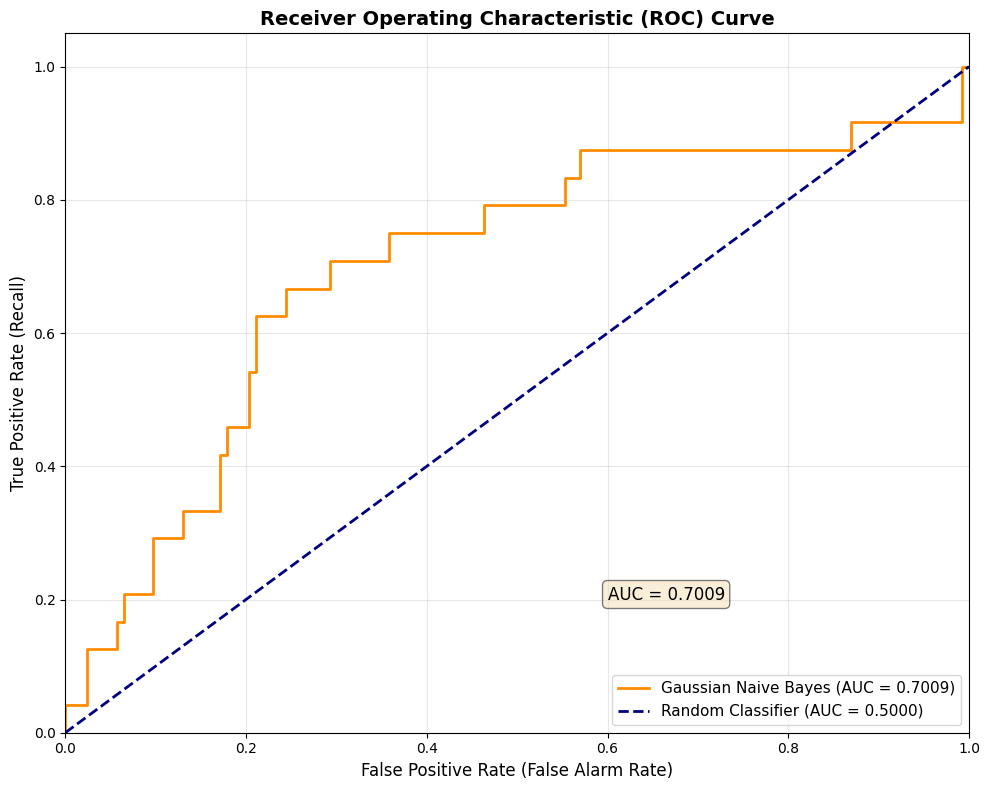

T17: ROC Curve Analysis

📊 ROC Curve Metrics:
   Model: Gaussian Naive Bayes
   AUC (Area Under Curve): 0.7009

   Interpretation:
   ✅ Fair classifier (AUC > 0.7)


In [54]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ===== T17: Plot ROC Curve =====

def plot_roc_curve(y_true, log_H_values, model_name='Gaussian Naive Bayes'):
    """
    Plot ROC curve for the classifier

    Parameters:
    -----------
    y_true : array
        Ground truth labels
    log_H_values : array
        Log likelihood ratios from Naive Bayes
    model_name : str
        Name of the model
    """

    # คำนวณ FPR, TPR สำหรับทุก threshold
    fpr, tpr, thresholds = roc_curve(y_true, log_H_values, pos_label=1)

    # คำนวณ AUC (Area Under Curve)
    roc_auc = auc(fpr, tpr)

    # Plot ROC Curve
    plt.figure(figsize=(10, 8))

    # Plot ROC curve
    plt.plot(fpr, tpr, color='darkorange', linewidth=2, 
             label=f'{model_name} (AUC = {roc_auc:.4f})')

    # Plot diagonal line (random classifier)
    plt.plot([0, 1], [0, 1], color='navy', linewidth=2, linestyle='--',
             label='Random Classifier (AUC = 0.5000)')

    # Formatting
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (False Alarm Rate)', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('Receiver Operating Characteristic (ROC) Curve', 
              fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)

    # เพิ่มข้อมูล
    plt.text(0.6, 0.2, f'AUC = {roc_auc:.4f}', 
             fontsize=12, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # แสดงข้อมูล
    print("=" * 70)
    print("T17: ROC Curve Analysis")
    print("=" * 70)
    print(f"\n📊 ROC Curve Metrics:")
    print(f"   Model: {model_name}")
    print(f"   AUC (Area Under Curve): {roc_auc:.4f}")
    print(f"\n   Interpretation:")
    if roc_auc > 0.9:
        print(f"   ✅ Excellent classifier (AUC > 0.9)")
    elif roc_auc > 0.8:
        print(f"   ✅ Good classifier (AUC > 0.8)")
    elif roc_auc > 0.7:
        print(f"   ✅ Fair classifier (AUC > 0.7)")
    elif roc_auc > 0.6:
        print(f"   ⚠️  Poor classifier (AUC > 0.6)")
    else:
        print(f"   ❌ Very poor classifier (AUC ≤ 0.6)")

    print("=" * 70)

    return fpr, tpr, thresholds, roc_auc

# ใช้งาน
fpr, tpr, thresholds, roc_auc = plot_roc_curve(y_true, log_H_values_gaussian)

## T18


Training with 5 bins
Training Naive Bayes Classifier

1. Prior Probabilities:
   P(leave) = 0.160998
   P(stay)  = 0.839002

2. Learning Likelihood Distributions...
   ✅ Age (continuous)
   ✅ MonthlyIncome (continuous)
   ✅ DistanceFromHome (continuous)
   ✅ JobRole (categorical)
   ✅ HourlyRate (categorical)
   ✅ MaritalStatus (categorical)

✅ Training complete!

📊 Performance Metrics (at threshold t=0):
   Accuracy:  0.7891
   Precision: 0.1818
   Recall:    0.0833
   F-score:   0.1143


Training with 10 bins
Training Naive Bayes Classifier

1. Prior Probabilities:
   P(leave) = 0.160998
   P(stay)  = 0.839002

2. Learning Likelihood Distributions...
   ✅ Age (continuous)
   ✅ MonthlyIncome (continuous)
   ✅ DistanceFromHome (continuous)
   ✅ JobRole (categorical)
   ✅ HourlyRate (categorical)
   ✅ MaritalStatus (categorical)

✅ Training complete!

📊 Performance Metrics (at threshold t=0):
   Accuracy:  0.8163
   Precision: 0.3333
   Recall:    0.1250
   F-score:   0.1818

T18: ROC 

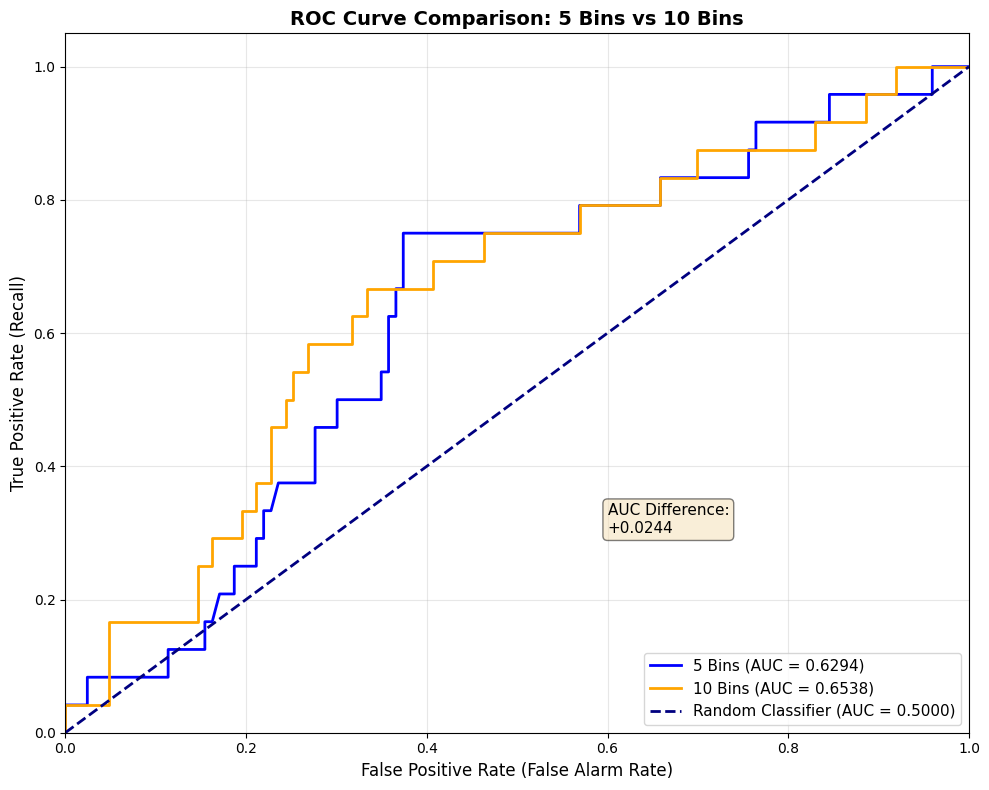


📊 ROC Curve Comparison:

Model                AUC          Performance         
----------------------------------------------------------------------
5 Bins               0.6294       Poor
10 Bins              0.6538       Poor

----------------------------------------------------------------------
Difference           0.0244      

💡 Analysis:

   ✅ 10 Bins performs better than 5 Bins
   → AUC improved by 3.88%
   → More bins allow better discrimination between classes

   Recommendation: Use 10 bins


In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# ===== T18: Compare ROC Curves for Different Bin Numbers =====

def create_bin_edges(df_train, continuous_features, n_bins=10):
    """
    สร้าง bin edges สำหรับ continuous features

    Parameters:
    -----------
    df_train : DataFrame
        Training data
    continuous_features : list
        List of continuous feature names
    n_bins : int
        Number of bins

    Returns:
    --------
    bin_edges_dict : dict
        Dictionary of bin edges for each feature
    """
    bin_edges_dict = {}

    for feature in continuous_features:
        # ดึงข้อมูลที่ไม่มี NaN
        train_data = df_train[feature].dropna()

        # สร้าง bin edges
        min_val = train_data.min()
        max_val = train_data.max()

        # สร้าง bins โดยเพิ่ม -inf และ +inf
        edges = np.linspace(min_val, max_val, n_bins + 1)
        edges = np.concatenate([[-np.inf], edges[1:-1], [np.inf]])

        bin_edges_dict[feature] = edges

    return bin_edges_dict


def train_and_evaluate_nb(df_train, df_test, continuous_features, 
                          categorical_features, n_bins=10):
    """
    Train Naive Bayes และ return log_H_values

    Parameters:
    -----------
    df_train : DataFrame
        Training data
    df_test : DataFrame
        Test data
    continuous_features : list
        List of continuous features
    categorical_features : list
        List of categorical features
    n_bins : int
        Number of bins for discretization

    Returns:
    --------
    log_H_values : array
        Log likelihood ratios for test set
    """

    print(f"\n{'='*70}")
    print(f"Training with {n_bins} bins")
    print(f"{'='*70}")

    # 1. สร้าง bin edges
    bin_edges_dict = create_bin_edges(df_train, continuous_features, n_bins)

    # 2. Train Naive Bayes
    nb = NaiveBayesClassifier(alpha=1.0)
    nb.fit(df_train, continuous_features, categorical_features, 
           bin_edges_dict, n_bins)

    # 3. Predict
    predictions, log_H_values = nb.predict(df_test)

    # 4. Evaluate
    y_true = df_test['Attrition'].values

    acc = accuracy_score(y_true, predictions)
    prec = precision_score(y_true, predictions, pos_label=1, zero_division=0)
    rec = recall_score(y_true, predictions, pos_label=1, zero_division=0)
    f1 = f1_score(y_true, predictions, pos_label=1, zero_division=0)

    print(f"\n📊 Performance Metrics (at threshold t=0):")
    print(f"   Accuracy:  {acc:.4f}")
    print(f"   Precision: {prec:.4f}")
    print(f"   Recall:    {rec:.4f}")
    print(f"   F-score:   {f1:.4f}")
    print(f"{'='*70}\n")

    return log_H_values


def compare_roc_curves_bins(y_true, log_H_5bins, log_H_10bins):
    """
    เปรียบเทียบ ROC curves สำหรับ bins ต่างกัน
    """

    print("=" * 70)
    print("T18: ROC Curve Comparison - Different Discretization Bins")
    print("=" * 70)

    # คำนวณ ROC curves
    fpr_5, tpr_5, _ = roc_curve(y_true, log_H_5bins, pos_label=1)
    fpr_10, tpr_10, _ = roc_curve(y_true, log_H_10bins, pos_label=1)

    # คำนวณ AUC
    auc_5 = auc(fpr_5, tpr_5)
    auc_10 = auc(fpr_10, tpr_10)

    # Plot
    plt.figure(figsize=(10, 8))

    plt.plot(fpr_5, tpr_5, color='blue', linewidth=2,
             label=f'5 Bins (AUC = {auc_5:.4f})')
    plt.plot(fpr_10, tpr_10, color='orange', linewidth=2,
             label=f'10 Bins (AUC = {auc_10:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', linewidth=2, linestyle='--',
             label='Random Classifier (AUC = 0.5000)')

    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate (False Alarm Rate)', fontsize=12)
    plt.ylabel('True Positive Rate (Recall)', fontsize=12)
    plt.title('ROC Curve Comparison: 5 Bins vs 10 Bins', 
              fontsize=14, fontweight='bold')
    plt.legend(loc="lower right", fontsize=11)
    plt.grid(alpha=0.3)

    # เพิ่มข้อมูล
    plt.text(0.6, 0.3, 
             f'AUC Difference:\n{auc_10 - auc_5:+.4f}',
             fontsize=11, 
             bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

    plt.tight_layout()
    plt.show()

    # แสดงผลเปรียบเทียบ
    print(f"\n📊 ROC Curve Comparison:\n")
    print(f"{'Model':<20} {'AUC':<12} {'Performance':<20}")
    print("-" * 70)
    print(f"{'5 Bins':<20} {auc_5:<12.4f} ", end="")

    if auc_5 > 0.8:
        print("Good")
    elif auc_5 > 0.7:
        print("Fair")
    else:
        print("Poor")

    print(f"{'10 Bins':<20} {auc_10:<12.4f} ", end="")

    if auc_10 > 0.8:
        print("Good")
    elif auc_10 > 0.7:
        print("Fair")
    else:
        print("Poor")

    print("\n" + "-" * 70)
    print(f"{'Difference':<20} {auc_10 - auc_5:<12.4f}")

    # วิเคราะห์
    print(f"\n💡 Analysis:\n")

    if auc_10 > auc_5:
        improvement = (auc_10 - auc_5) / auc_5 * 100
        print(f"   ✅ 10 Bins performs better than 5 Bins")
        print(f"   → AUC improved by {improvement:.2f}%")
        print(f"   → More bins allow better discrimination between classes")
        print(f"\n   Recommendation: Use 10 bins")
    elif auc_5 > auc_10:
        improvement = (auc_5 - auc_10) / auc_10 * 100
        print(f"   ✅ 5 Bins performs better than 10 Bins")
        print(f"   → AUC improved by {improvement:.2f}%")
        print(f"   → Fewer bins reduce overfitting on sparse data")
        print(f"\n   Recommendation: Use 5 bins")
    else:
        print(f"   ⚖️  Both perform equally")
        print(f"   → No significant difference in AUC")
        print(f"\n   Recommendation: Use 5 bins (simpler model)")

    print("=" * 70)

    return {
        '5_bins': {'fpr': fpr_5, 'tpr': tpr_5, 'auc': auc_5},
        '10_bins': {'fpr': fpr_10, 'tpr': tpr_10, 'auc': auc_10}
    }


# ===== ใช้งาน =====

# ระบุ features
continuous_features = ['Age', 'MonthlyIncome', 'DistanceFromHome']
categorical_features = ['JobRole', 'HourlyRate', 'MaritalStatus']  # ปรับตามข้อมูลของคุณ

# Train ด้วย 5 bins
log_H_5bins = train_and_evaluate_nb(
    df_train, df_test, 
    continuous_features, categorical_features, 
    n_bins=5
)

# Train ด้วย 10 bins
log_H_10bins = train_and_evaluate_nb(
    df_train, df_test, 
    continuous_features, categorical_features, 
    n_bins=10
)

# เปรียบเทียบ ROC curves
y_true = df_test['Attrition'].values
results = compare_roc_curves_bins(y_true, log_H_5bins, log_H_10bins)

## OT4

In [62]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt

# ===== OT4: Classifier Variance Analysis =====

def evaluate_classifier_variance(df, n_iterations=10, test_size=0.1, 
                                 n_bins=10, random_state_base=42):
    """
    ประเมิน variance ของ classifier โดย shuffle data หลายครั้ง

    Parameters:
    -----------
    df : DataFrame
        Complete dataset
    n_iterations : int
        จำนวนครั้งที่จะ shuffle และ train ใหม่
    test_size : float
        สัดส่วนของ test set (0.1 = 10%)
    n_bins : int
        Number of bins for histogram discretization
    random_state_base : int
        Base random state for reproducibility

    Returns:
    --------
    results : dict
        Dictionary containing all metrics
    """

    print("=" * 70)
    print("OT4: Classifier Variance Analysis")
    print("=" * 70)
    print(f"\nRunning {n_iterations} iterations with different train/test splits...")
    print(f"Test size: {test_size*100:.0f}%")
    print(f"Number of bins: {n_bins}")
    print("=" * 70)

    # เก็บผลลัพธ์
    accuracies = []
    precisions = []
    recalls = []
    f1_scores = []

    # ระบุ features
    continuous_features = ['Age', 'MonthlyIncome', 'DistanceFromHome']
    categorical_features = ['JobRole', 'HourlyRate', 'MaritalStatus']  # ปรับตามข้อมูลของคุณ

    # Run multiple iterations
    for i in range(n_iterations):
        print(f"\n{'─'*70}")
        print(f"Iteration {i+1}/{n_iterations}")
        print(f"{'─'*70}")

        # 1. Shuffle และแบ่ง train/test
        df_train, df_test = train_test_split(
            df, 
            test_size=test_size, 
            random_state=random_state_base + i,  # เปลี่ยน random state ทุกครั้ง
            stratify=df['Attrition']  # รักษาสัดส่วน class
        )

        print(f"Train size: {len(df_train)}, Test size: {len(df_test)}")

        # 2. สร้าง bin edges
        bin_edges_dict = {}
        for feature in continuous_features:
            train_data = df_train[feature].dropna()
            min_val = train_data.min()
            max_val = train_data.max()
            edges = np.linspace(min_val, max_val, n_bins + 1)
            edges = np.concatenate([[-np.inf], edges[1:-1], [np.inf]])
            bin_edges_dict[feature] = edges

        # 3. Train Naive Bayes
        nb = NaiveBayesClassifier(alpha=1.0)
        nb.fit(df_train, continuous_features, categorical_features, 
               bin_edges_dict, n_bins)

        # 4. Predict
        predictions, log_H_values = nb.predict(df_test)

        # 5. Evaluate
        y_true = df_test['Attrition'].values

        acc = accuracy_score(y_true, predictions)
        prec = precision_score(y_true, predictions, pos_label=1, zero_division=0)
        rec = recall_score(y_true, predictions, pos_label=1, zero_division=0)
        f1 = f1_score(y_true, predictions, pos_label=1, zero_division=0)

        # เก็บผลลัพธ์
        accuracies.append(acc)
        precisions.append(prec)
        recalls.append(rec)
        f1_scores.append(f1)

        print(f"Accuracy:  {acc:.4f}")
        print(f"Precision: {prec:.4f}")
        print(f"Recall:    {rec:.4f}")
        print(f"F-score:   {f1:.4f}")

    # แปลงเป็น numpy arrays
    accuracies = np.array(accuracies)
    precisions = np.array(precisions)
    recalls = np.array(recalls)
    f1_scores = np.array(f1_scores)

    # คำนวณ statistics
    print("\n" + "=" * 70)
    print("SUMMARY STATISTICS")
    print("=" * 70)

    print(f"\n📊 Accuracy:")
    print(f"   Mean:     {accuracies.mean():.4f}")
    print(f"   Variance: {accuracies.var():.6f}")
    print(f"   Std Dev:  {accuracies.std():.6f}")
    print(f"   Min:      {accuracies.min():.4f}")
    print(f"   Max:      {accuracies.max():.4f}")
    print(f"   Range:    {accuracies.max() - accuracies.min():.4f}")

    print(f"\n📊 Precision:")
    print(f"   Mean:     {precisions.mean():.4f}")
    print(f"   Variance: {precisions.var():.6f}")
    print(f"   Std Dev:  {precisions.std():.6f}")

    print(f"\n📊 Recall:")
    print(f"   Mean:     {recalls.mean():.4f}")
    print(f"   Variance: {recalls.var():.6f}")
    print(f"   Std Dev:  {recalls.std():.6f}")

    print(f"\n📊 F-score:")
    print(f"   Mean:     {f1_scores.mean():.4f}")
    print(f"   Variance: {f1_scores.var():.6f}")
    print(f"   Std Dev:  {f1_scores.std():.6f}")

    # การตีความ
    print(f"\n💡 Interpretation:")

    acc_cv = accuracies.std() / accuracies.mean()  # Coefficient of Variation

    if acc_cv < 0.05:
        print(f"   ✅ Very stable classifier (CV = {acc_cv:.4f} < 0.05)")
        print(f"   → Low variance, consistent performance")
    elif acc_cv < 0.10:
        print(f"   ✅ Stable classifier (CV = {acc_cv:.4f} < 0.10)")
        print(f"   → Acceptable variance")
    else:
        print(f"   ⚠️  Unstable classifier (CV = {acc_cv:.4f} ≥ 0.10)")
        print(f"   → High variance, performance depends on train/test split")

    print("=" * 70)

    # เก็บผลลัพธ์
    results = {
        'accuracies': accuracies,
        'precisions': precisions,
        'recalls': recalls,
        'f1_scores': f1_scores,
        'mean_accuracy': accuracies.mean(),
        'var_accuracy': accuracies.var(),
        'std_accuracy': accuracies.std(),
        'cv_accuracy': acc_cv
    }

    return results

# ใช้งาน
results = evaluate_classifier_variance(df, n_iterations=10, test_size=0.1, n_bins=10)

OT4: Classifier Variance Analysis

Running 10 iterations with different train/test splits...
Test size: 10%
Number of bins: 10

──────────────────────────────────────────────────────────────────────
Iteration 1/10
──────────────────────────────────────────────────────────────────────
Train size: 1323, Test size: 147
Training Naive Bayes Classifier

1. Prior Probabilities:
   P(leave) = 0.160998
   P(stay)  = 0.839002

2. Learning Likelihood Distributions...
   ✅ Age (continuous)
   ✅ MonthlyIncome (continuous)
   ✅ DistanceFromHome (continuous)
   ✅ JobRole (categorical)
   ✅ HourlyRate (categorical)
   ✅ MaritalStatus (categorical)

✅ Training complete!
Accuracy:  0.8163
Precision: 0.3333
Recall:    0.1250
F-score:   0.1818

──────────────────────────────────────────────────────────────────────
Iteration 2/10
──────────────────────────────────────────────────────────────────────
Train size: 1323, Test size: 147
Training Naive Bayes Classifier

1. Prior Probabilities:
   P(leave) = 0.1